# Benchmark: Classical (Non-ML) Methods

Benchmark all spectral similarity scorers on close-set evaluation (clean + noisy).

**Methods:** cosine, cosine_hungarian, modified_cosine, neutral_loss_cosine, entropy  
**Filtering:** Precursor m/z ±0.5 Da (binary search)  
**Eval sets:** Clean close-set + noisy close-set (mild/moderate/severe/extreme)  
**Metrics:** top-k accuracy, class-level accuracy, MRR, query time, candidate set size  
**Brute-force sanity check:** Small sample, no precursor filter

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

from src.data.loader import load_library
from src.data.evaluation import (
    sample_queries,
    save_split_eval_sets, load_split_eval_sets,
)
from src.data.augment import NOISE_PROFILES
from src.models.classical import ClassicalSearcher
from src.benchmark import run_benchmark
from src.utils.metrics import top_k_accuracy

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=0.95)
plt.rcParams.update({
    "figure.figsize": (6, 2),
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "svg.fonttype": "none",
})

%matplotlib inline

## 1. Load Library & Create Evaluation Sets

In [2]:
ref_df = load_library()
print(f"Reference library: {len(ref_df):,} spectra")

# Three eval sets: 0% / 50% / 100% isomer fraction (100 queries each)
from src.data.evaluation import _DATA_DIR
if not (_DATA_DIR / "eval_mixed.parquet").exists():
    save_split_eval_sets(ref_df, n=100, seed=42)
eval_no_iso, eval_mixed, eval_with_iso = load_split_eval_sets()

EVAL_SETS_NAMED = {
    "0% isomer":   eval_no_iso,
    "50% isomer":  eval_mixed,
    "100% isomer": eval_with_iso,
}

for label, ev in EVAL_SETS_NAMED.items():
    print(f"  {label:12s}: {len(ev['clean'])} queries per noise level")

# Combined eval_sets for aggregate downstream analyses
eval_sets = {}
for noise_name in eval_no_iso:
    eval_sets[noise_name] = eval_no_iso[noise_name] + eval_mixed[noise_name] + eval_with_iso[noise_name]
print(f"  {'combined':12s}: {len(eval_sets['clean'])} queries per noise level")

Removed 384 spectra with <2 peaks
Reference library: 551,890 spectra
  0% isomer   : 100 queries per noise level
  50% isomer  : 100 queries per noise level
  100% isomer : 100 queries per noise level
  combined    : 300 queries per noise level


## 2. Build Searchers

All 5 scoring methods from `src/utils/spectrum.py`, each with precursor m/z filtering (±0.5 Da).

In [3]:
METHODS = ["cosine", "cosine_hungarian", "modified_cosine", "neutral_loss_cosine", "entropy"]

methods = {}
for method_name in METHODS:
    searcher = ClassicalSearcher(ref_df, method=method_name, precursor_tol=0.5)
    methods[method_name] = searcher.search
    print(f"Built: {method_name}")

Built: cosine
Built: cosine_hungarian
Built: modified_cosine
Built: neutral_loss_cosine
Built: entropy


## 3. Run Benchmark

Run all 5 methods on both eval sets, then compare.

In [4]:
# Benchmark all three eval sets
all_results = {}
for label, ev in EVAL_SETS_NAMED.items():
    print(f"\n{'='*60}")
    print(f"  Eval set: {label} ({len(ev['clean'])} queries)")
    print(f"{'='*60}")
    res = run_benchmark(methods, ev, top_k=10)
    res["eval_set"] = label
    all_results[label] = res

split_results = pd.concat(list(all_results.values()), ignore_index=True)

print(f"\n{'='*60}")
print("  Per eval set results")
print(f"{'='*60}")
print(split_results[["eval_set", "method", "noise", "top_1", "class_top_1", "mrr"]].to_string(index=False))


  Eval set: 0% isomer (100 queries)


  cosine               | clean      | top1=1.000  cls1=1.000  mrr=1.000  49.0 ms/query  cands=268


  cosine               | mild       | top1=0.990  cls1=0.990  mrr=0.995  30.3 ms/query  cands=268


  cosine               | moderate   | top1=0.960  cls1=0.980  mrr=0.973  27.6 ms/query  cands=268


  cosine               | severe     | top1=0.790  cls1=0.840  mrr=0.841  27.1 ms/query  cands=268


...

  entropy              | clean      | top1=0.370  cls1=1.000  mrr=0.631  64.5 ms/query  cands=273


  entropy              | mild       | top1=0.320  cls1=0.980  mrr=0.576  60.0 ms/query  cands=273


  entropy              | moderate   | top1=0.260  cls1=0.940  mrr=0.485  54.0 ms/query  cands=273


  entropy              | severe     | top1=0.160  cls1=0.770  mrr=0.322  36.5 ms/query  cands=273


  entropy              | extreme    | top1=0.050  cls1=0.430  mrr=0.117  29.5 ms/query  cands=273

  Per eval set results
   eval_set              method    noise  top_1  class_top_1      mrr
  0% isomer              cosine    clean   1.00         1.00 1.000000
  0% isomer              cosine     mild   0.99         0.99 0.995000
  0% isomer              cosine moderate   0.96         0.98 0.973333
  0% isomer              cosine   severe   0.79         0.84 0.840500
  0% isomer              cosine  extreme   0.43         0.59 0.557302
  0% isomer    cosine_hungarian    clean   1.00         1.00 1.000000
  0% isomer    cosine_hungarian     mild   0.99         0.99 0.995000
  0% isomer    cosine_hungarian moderate   0.96         0.98 0.973333
  0% isomer    cosine_hungarian   severe   0.79         0.84 0.840500
  0% isomer    cosine_hungarian  extreme   0.43         0.59 0.557302
  0% isomer     modified_cosine    clean   0.85         1.00 0.923333
  0% isomer     modified_cosine     mi

In [5]:
# Save for use in downstream notebooks (NB02+)
split_results.to_parquet("../data/benchmark_classical.parquet", index=False)
print(f"Saved {len(split_results)} rows to data/benchmark_classical.parquet")

Saved 75 rows to data/benchmark_classical.parquet


## 4. Isomer Fraction vs Accuracy

Three eval sets with increasing isomer fraction (0%, 50%, 100%) reveal how isomer degeneracy drives accuracy down independently of noise.

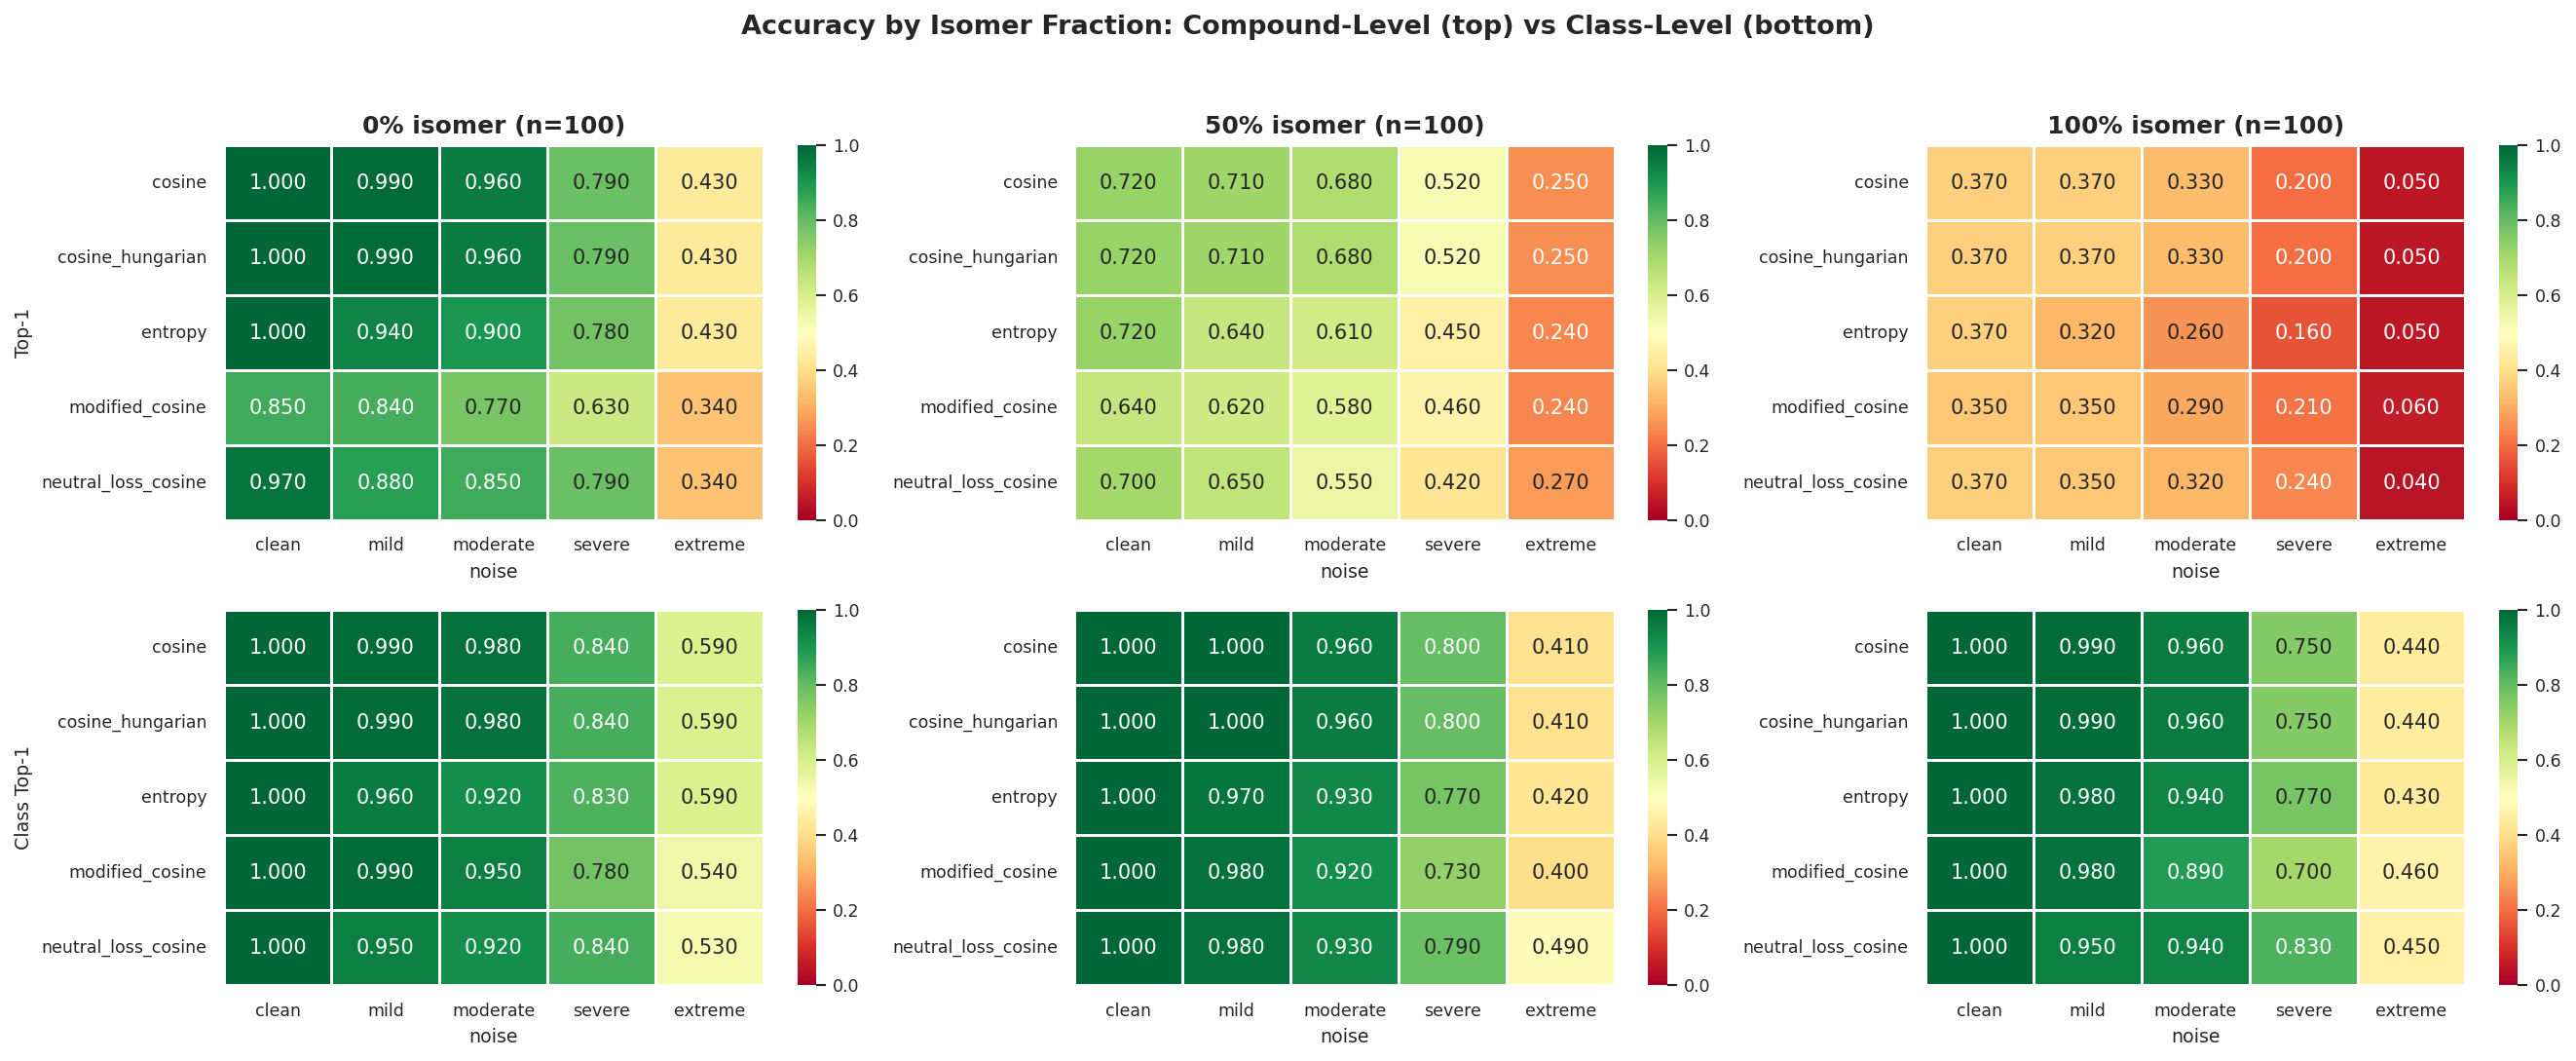

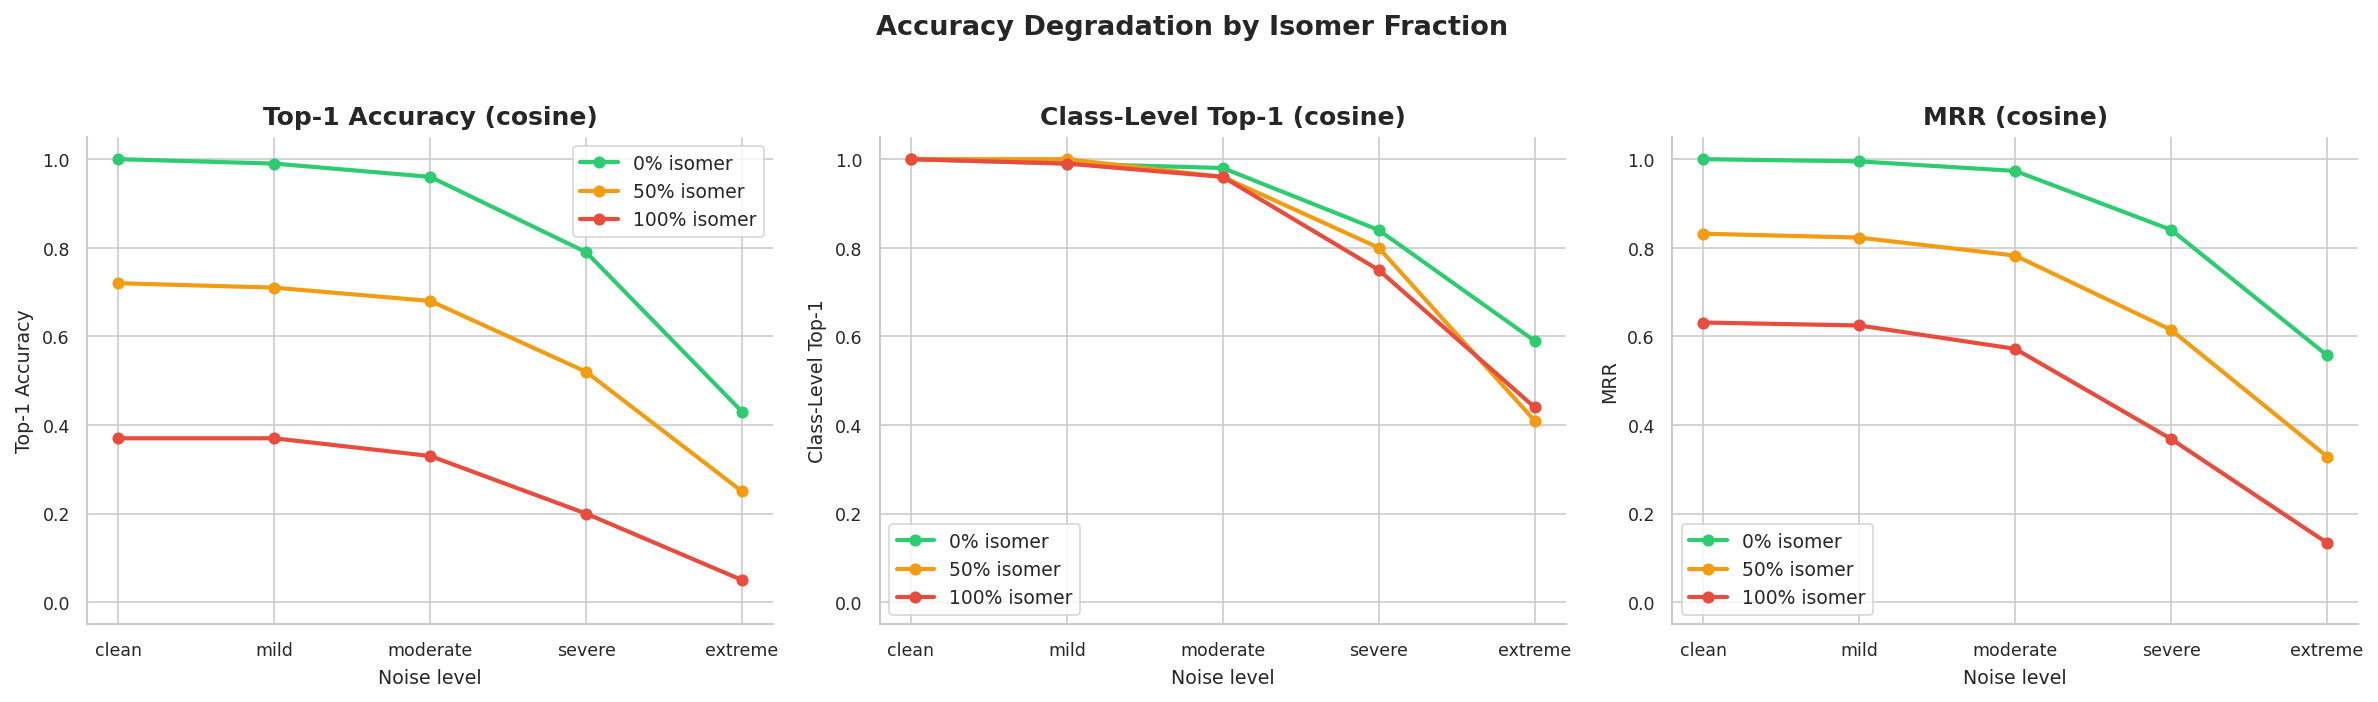

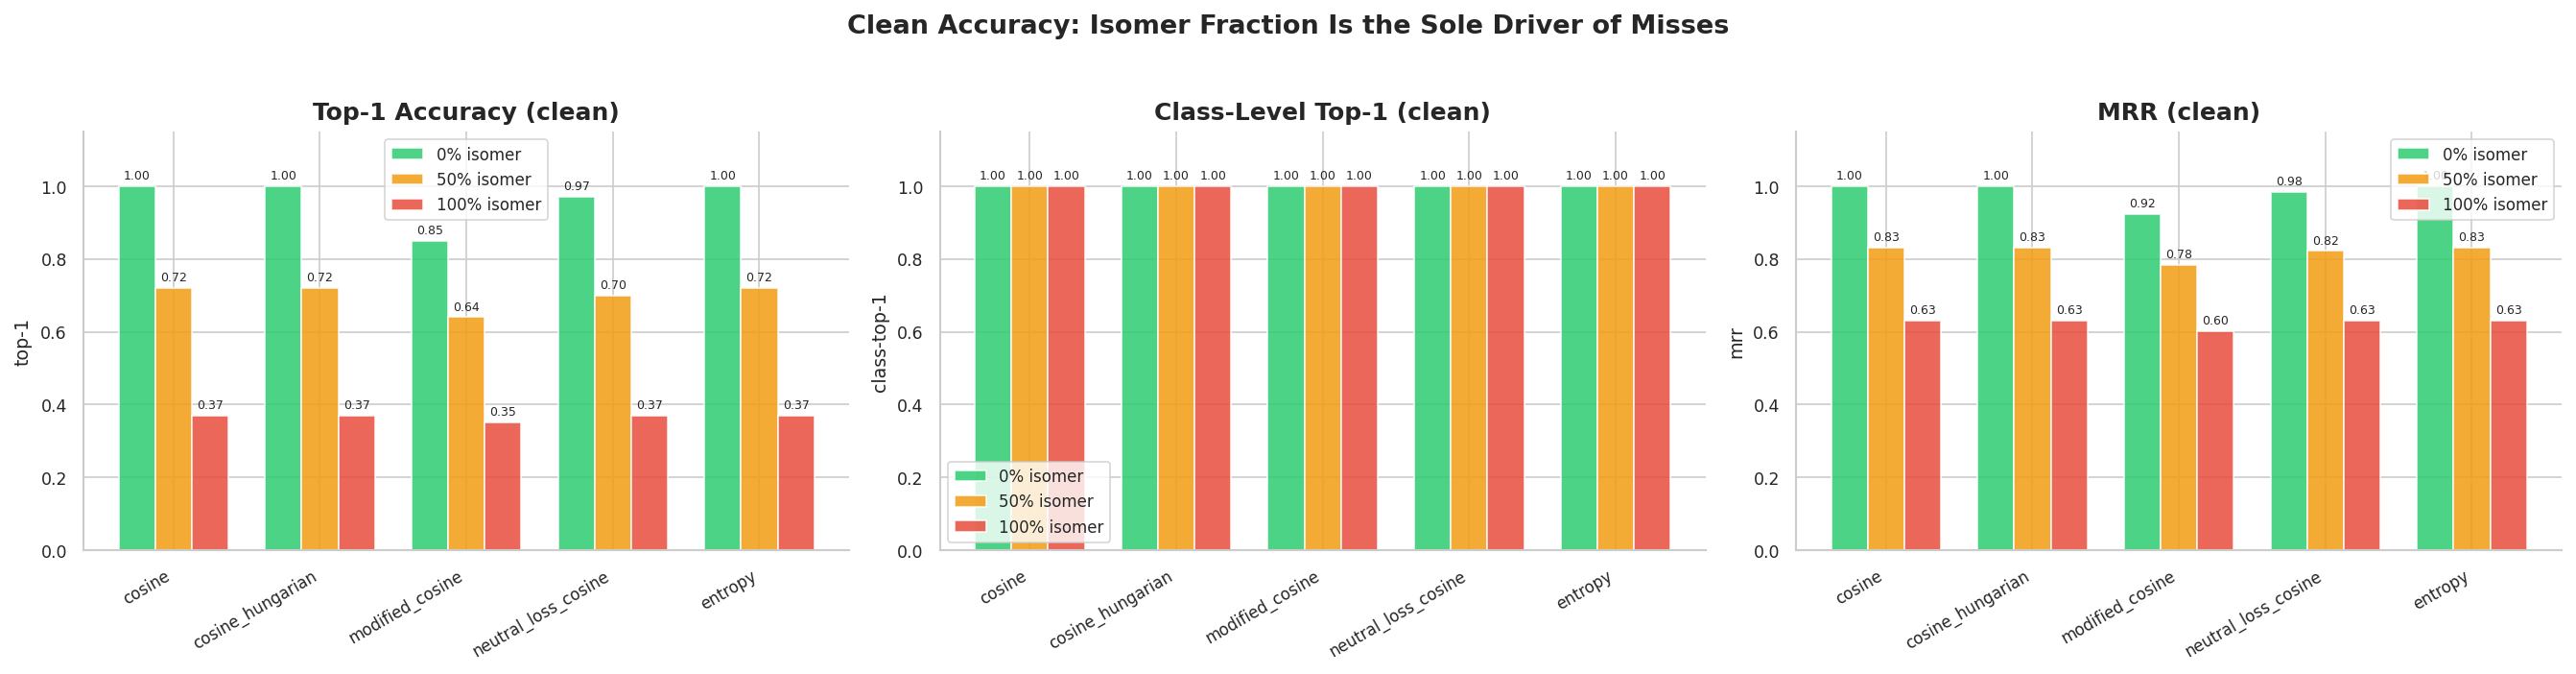

Cosine accuracy by isomer fraction:

  0% isomer:
    clean     : top1=1.000  class_top1=1.000  mrr=1.000
    mild      : top1=0.990  class_top1=0.990  mrr=0.995
    moderate  : top1=0.960  class_top1=0.980  mrr=0.973
    severe    : top1=0.790  class_top1=0.840  mrr=0.841
    extreme   : top1=0.430  class_top1=0.590  mrr=0.557

  50% isomer:
    clean     : top1=0.720  class_top1=1.000  mrr=0.832
    mild      : top1=0.710  class_top1=1.000  mrr=0.823
    moderate  : top1=0.680  class_top1=0.960  mrr=0.782
    severe    : top1=0.520  class_top1=0.800  mrr=0.615
    extreme   : top1=0.250  class_top1=0.410  mrr=0.329

  100% isomer:
    clean     : top1=0.370  class_top1=1.000  mrr=0.631
    mild      : top1=0.370  class_top1=0.990  mrr=0.625
    moderate  : top1=0.330  class_top1=0.960  mrr=0.572
    severe    : top1=0.200  class_top1=0.750  mrr=0.368
    extreme   : top1=0.050  class_top1=0.440  mrr=0.134


In [6]:
noise_order = ["clean", "mild", "moderate", "severe", "extreme"]
set_labels = list(EVAL_SETS_NAMED.keys())
set_colors = {"0% isomer": "#2ecc71", "50% isomer": "#f39c12", "100% isomer": "#e74c3c"}

# --- Figure 1: Accuracy heatmaps (2×3: top_1 and class_top_1) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
for row, (metric, row_title) in enumerate([("top_1", "Top-1"), ("class_top_1", "Class Top-1")]):
    for col, label in enumerate(set_labels):
        ax = axes[row, col]
        pivot = all_results[label].pivot(index="method", columns="noise", values=metric)
        pivot = pivot[noise_order]
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                    linewidths=0.5, ax=ax)
        if row == 0:
            ax.set_title(f"{label} (n={len(EVAL_SETS_NAMED[label]['clean'])})", fontweight="bold")
        ax.set_ylabel(row_title if col == 0 else "")
plt.suptitle("Accuracy by Isomer Fraction: Compound-Level (top) vs Class-Level (bottom)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# --- Figure 2: Degradation curves (cosine, 3 sets) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, title in zip(axes, ["top_1", "class_top_1", "mrr"],
                              ["Top-1 Accuracy", "Class-Level Top-1", "MRR"]):
    for label in set_labels:
        sub = all_results[label]
        cos = sub[sub["method"] == "cosine"].set_index("noise").loc[noise_order]
        ax.plot(noise_order, cos[metric], marker="o", linewidth=2,
                 color=set_colors[label], label=label)
    ax.set_xlabel("Noise level")
    ax.set_ylabel(title)
    ax.set_title(f"{title} (cosine)", fontweight="bold")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
plt.suptitle("Accuracy Degradation by Isomer Fraction",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# --- Figure 3: Bar chart (clean accuracy, all methods × 3 sets) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
x = np.arange(len(METHODS))
width = 0.25

for ax, metric, title in zip(axes, ["top_1", "class_top_1", "mrr"],
                              ["Top-1 Accuracy (clean)", "Class-Level Top-1 (clean)", "MRR (clean)"]):
    for j, label in enumerate(set_labels):
        vals = [all_results[label][(all_results[label]["method"] == m) &
                (all_results[label]["noise"] == "clean")][metric].values[0] for m in METHODS]
        bars = ax.bar(x + (j - 1) * width, vals, width, label=label,
                      color=set_colors[label], alpha=0.85)
        for i, v in enumerate(vals):
            ax.text(x[i] + (j - 1) * width, v + 0.02, f"{v:.2f}",
                    ha="center", fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(METHODS, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(metric.replace("_", "-"))
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)

plt.suptitle("Clean Accuracy: Isomer Fraction Is the Sole Driver of Misses",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("Cosine accuracy by isomer fraction:")
for label in set_labels:
    print(f"\n  {label}:")
    for noise in noise_order:
        row = all_results[label]
        cos = row[(row["method"] == "cosine") & (row["noise"] == noise)]
        print(f"    {noise:10s}: top1={cos['top_1'].values[0]:.3f}  "
              f"class_top1={cos['class_top_1'].values[0]:.3f}  mrr={cos['mrr'].values[0]:.3f}")

## 5. Brute-Force Sanity Check

Score a small sample against the entire library (no precursor filter) to measure brute-force timing.

In [7]:
N_BRUTE = 3

brute_sample = sample_queries(ref_df, n=N_BRUTE, seed=99)
from src.data.augment import create_evaluation_sets
brute_eval = create_evaluation_sets(brute_sample, {"clean": NOISE_PROFILES["clean"]}, seed=99)
brute_queries = brute_eval["clean"]

brute_searcher = ClassicalSearcher(ref_df, method="cosine", precursor_filter=False)

print(f"Brute-force: {N_BRUTE} queries x {len(ref_df):,} candidates each")
print("Running... (this will take a few minutes)")

preds = []
gts = []
n_ties_list = []
t0 = time.perf_counter()
for i, q in enumerate(brute_queries):
    results = brute_searcher.search(q, top_k=500)
    preds.append([r["name"] for r in results])
    gts.append(q["ground_truth_name"])

    top_score = results[0]["score"]
    n_ties = sum(1 for r in results if abs(r["score"] - top_score) < 1e-9)
    n_ties_list.append(n_ties)

    elapsed_so_far = time.perf_counter() - t0
    hit = results[0]["name"] == q["ground_truth_name"]
    print(f"  Query {i+1}/{N_BRUTE}: "
          f"top1={'HIT' if hit else 'MISS'}, "
          f"score={top_score:.4f}, "
          f"ties={n_ties}, "
          f"{elapsed_so_far/(i+1)*1000:.0f} ms/query")

total_time = time.perf_counter() - t0
ms_per_query = total_time / N_BRUTE * 1000

print(f"\nBrute-force top-1 accuracy: {top_k_accuracy(preds, gts, 1):.1%}")
print(f"Queries with ties at top score: {sum(1 for t in n_ties_list if t > 1)}/{N_BRUTE}")
print(f"Time per query: {ms_per_query:.0f} ms")
print(f"Extrapolated for 200 queries: {ms_per_query * 200 / 1000 / 60:.1f} min")
print(f"\nNote: brute-force has the same isomer degeneracy as precursor-filtered search.")
print(f"Any 100% result on N={N_BRUTE} is a small-sample artifact, not real discrimination.")

Brute-force: 3 queries x 551,890 candidates each
Running... (this will take a few minutes)
  Query 1/3: top1=HIT, score=1.0000, ties=1, 59448 ms/query
  Query 2/3: top1=HIT, score=1.0000, ties=1, 58122 ms/query
  Query 3/3: top1=HIT, score=1.0000, ties=1, 57177 ms/query

Brute-force top-1 accuracy: 100.0%
Queries with ties at top score: 0/3
Time per query: 57177 ms
Extrapolated for 200 queries: 190.6 min

Note: brute-force has the same isomer degeneracy as precursor-filtered search.
Any 100% result on N=3 is a small-sample artifact, not real discrimination.


## 6. Accuracy Degradation Heatmap

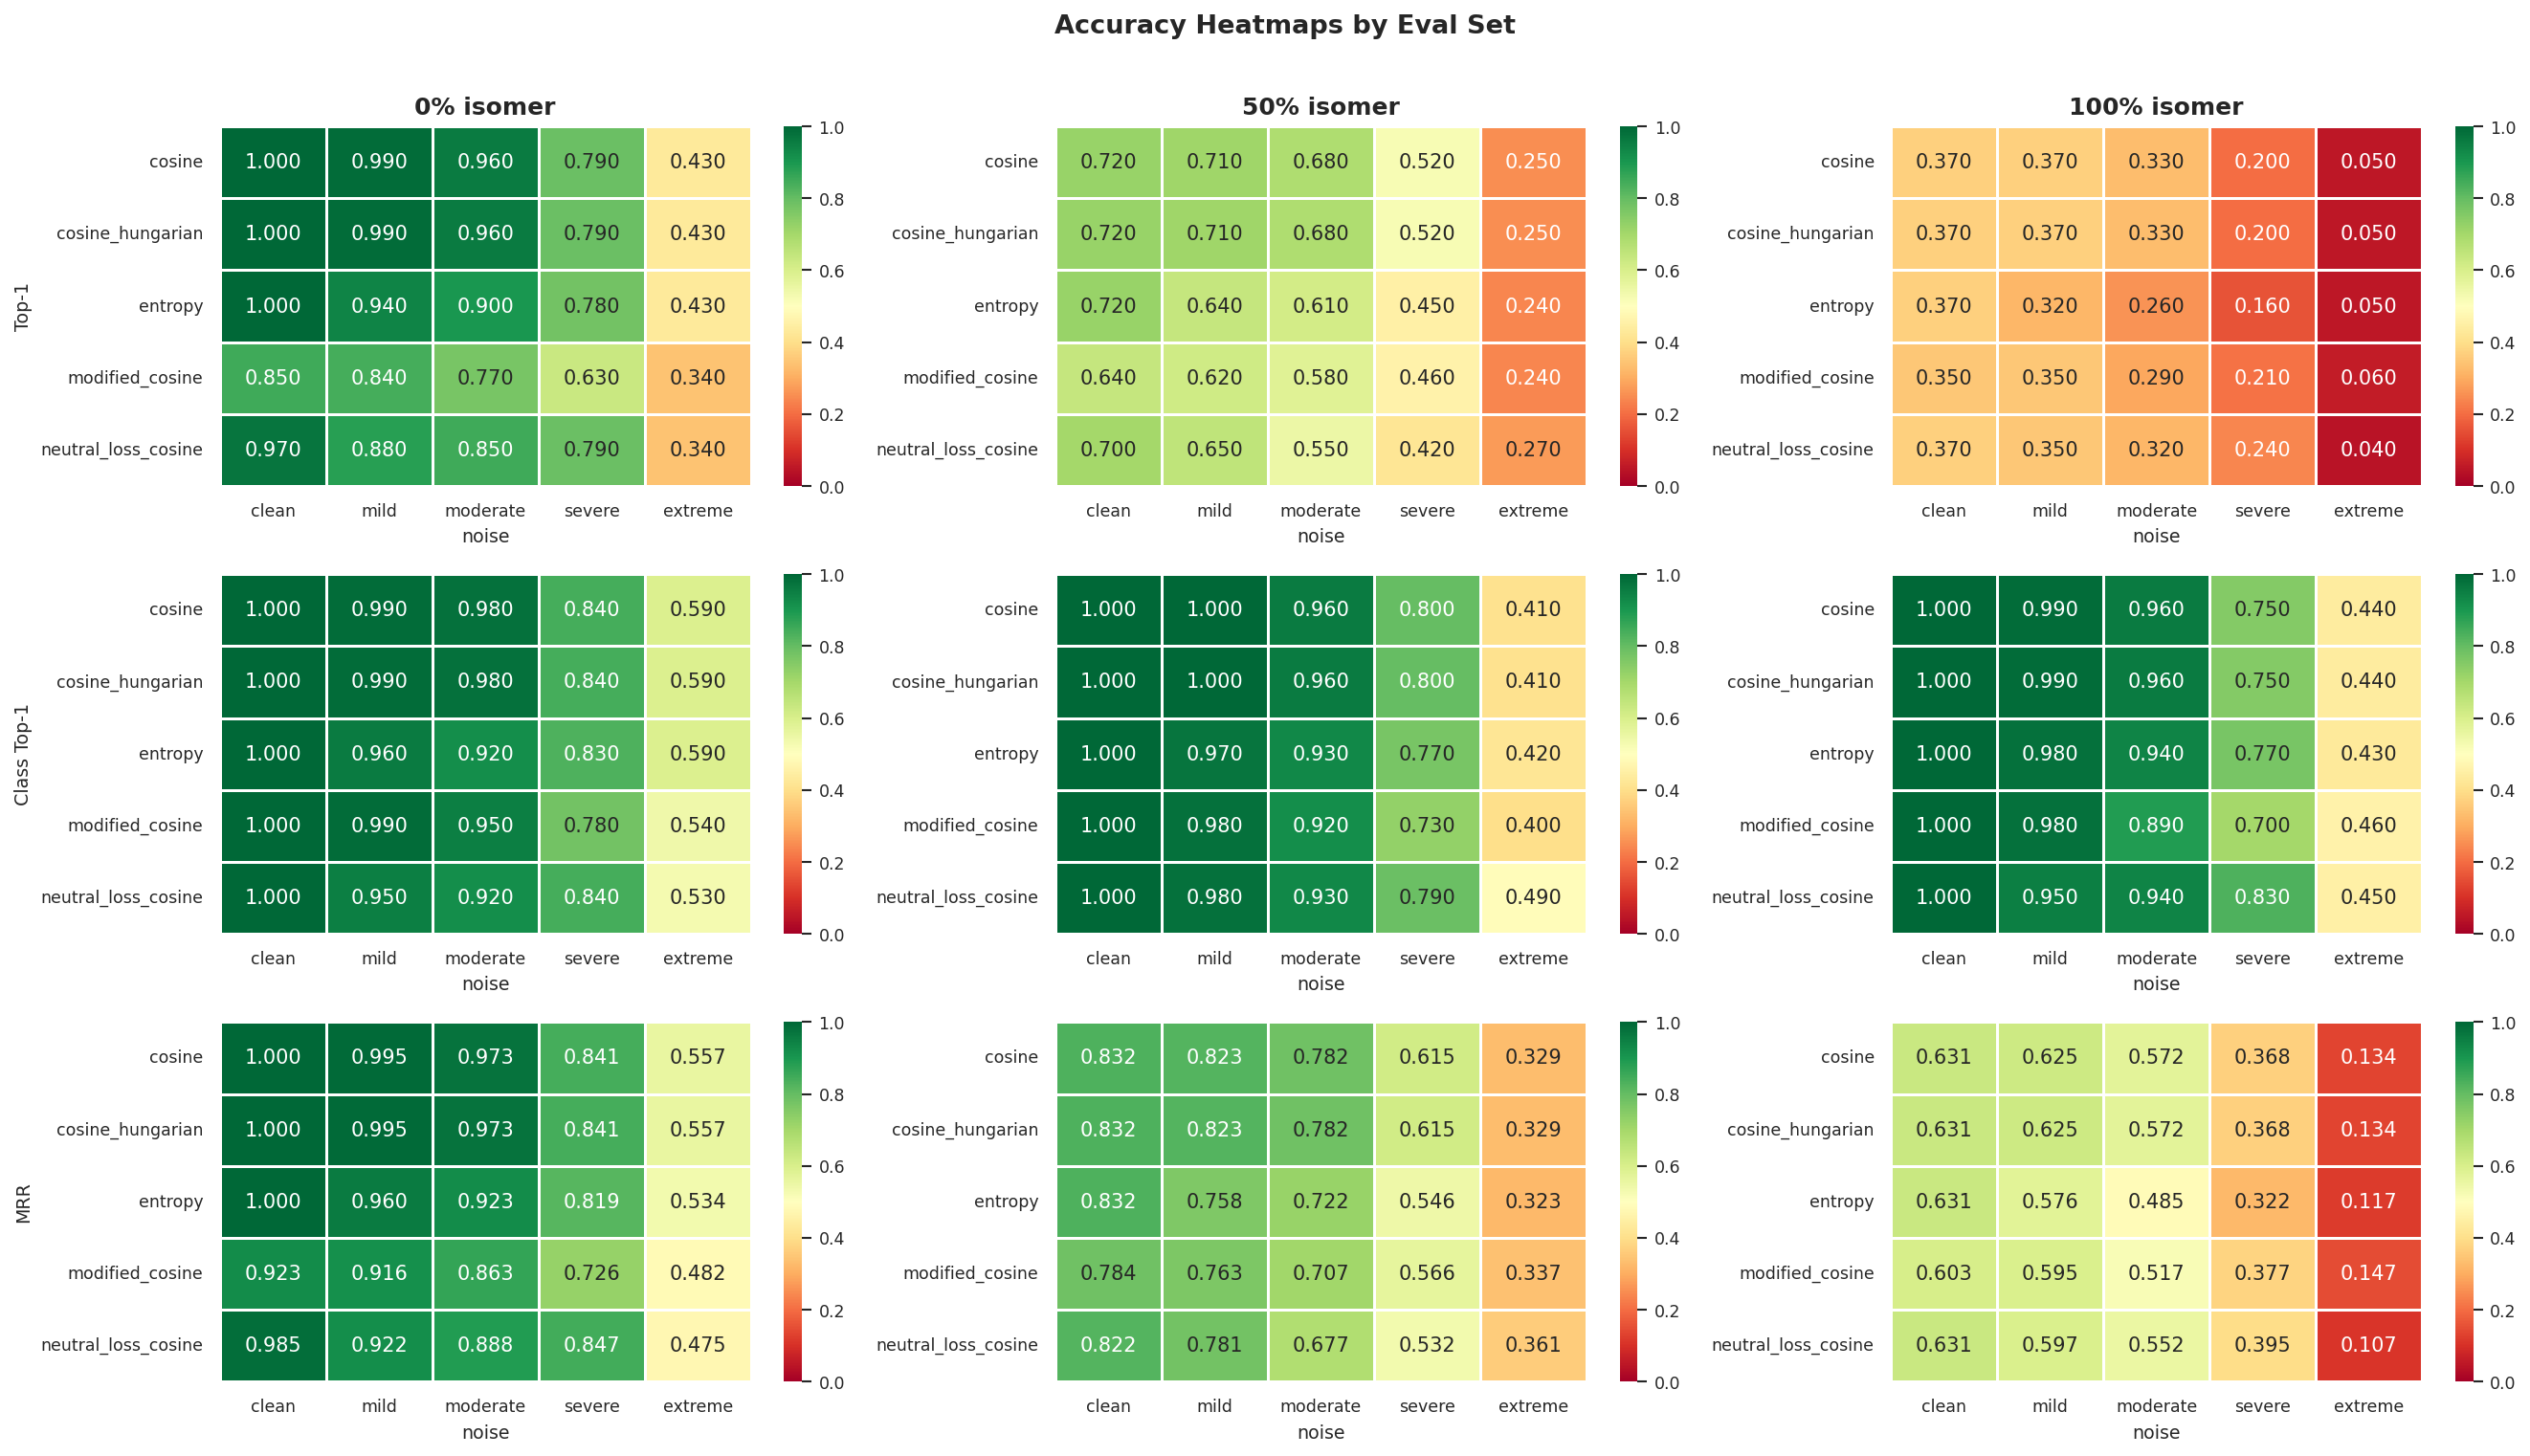

In [8]:
noise_order = ["clean", "mild", "moderate", "severe", "extreme"]
set_labels = list(EVAL_SETS_NAMED.keys())

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
for row, (metric, row_title) in enumerate([("top_1", "Top-1"), ("class_top_1", "Class Top-1"), ("mrr", "MRR")]):
    for col, label in enumerate(set_labels):
        ax = axes[row, col]
        pivot = all_results[label].pivot(index="method", columns="noise", values=metric)
        pivot = pivot[noise_order]
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                    linewidths=0.5, ax=ax)
        if row == 0:
            ax.set_title(label, fontweight="bold")
        ax.set_ylabel(row_title if col == 0 else "")

plt.suptitle("Accuracy Heatmaps by Eval Set",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Candidate Set Size

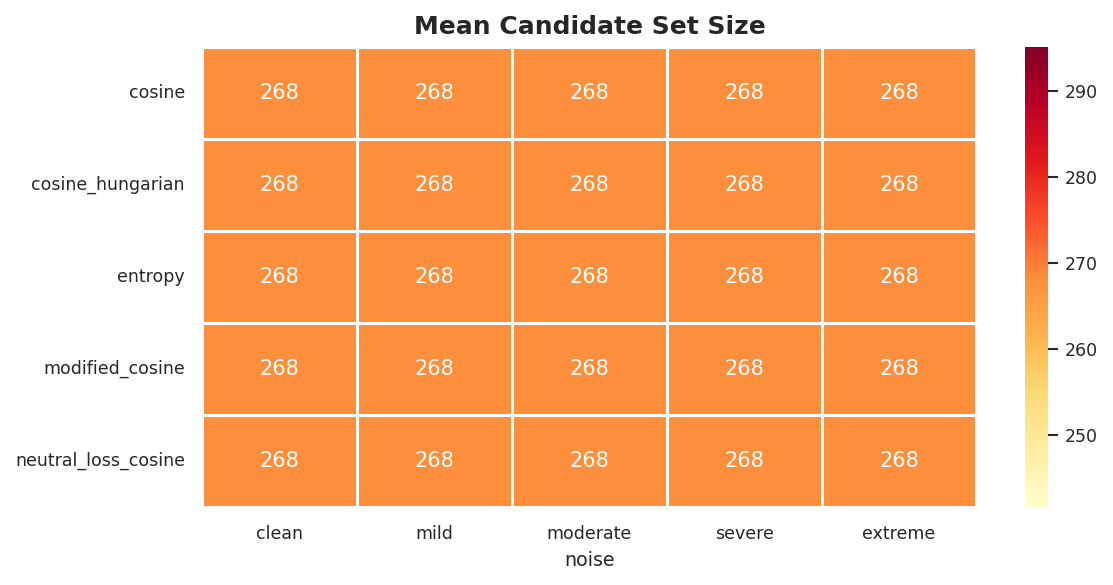

Note: all methods share the same precursor filter (±0.5 Da),
so candidate counts are identical across methods and eval sets.


In [9]:
# Candidate counts are determined by precursor filter, not eval set — use first set
_any_res = list(all_results.values())[0]
cand_pivot = _any_res.pivot(index="method", columns="noise", values="mean_candidates")
noise_order = ["clean", "mild", "moderate", "severe", "extreme"]
cand_pivot = cand_pivot[noise_order]

# All methods use the same precursor index, so candidate counts should be identical
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cand_pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax)
ax.set_title("Mean Candidate Set Size", fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Note: all methods share the same precursor filter (±0.5 Da),")
print("so candidate counts are identical across methods and eval sets.")

## 8. Query Time Comparison

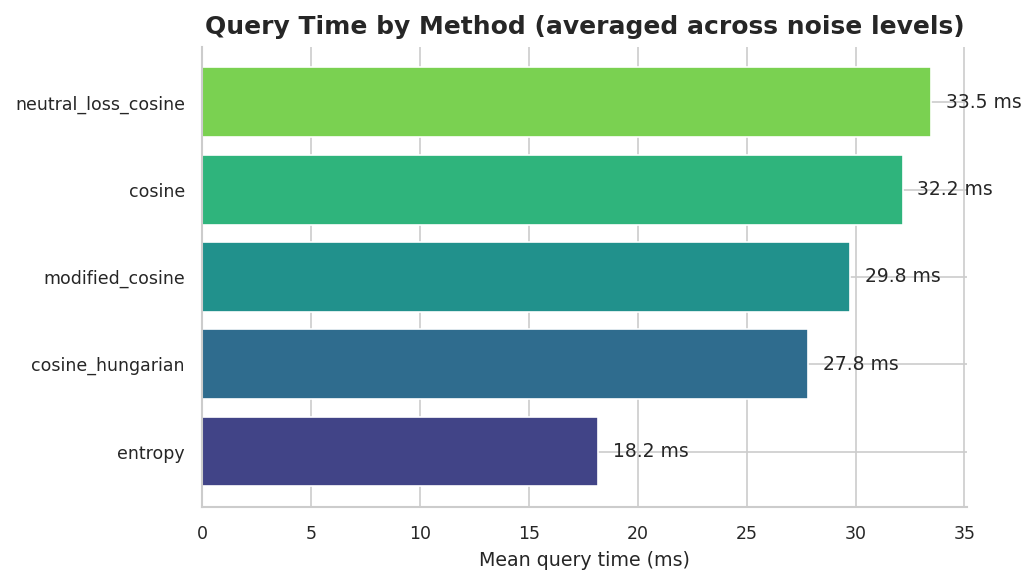

In [10]:
# Query time is eval-set independent — use first set
_any_res = list(all_results.values())[0]
time_by_method = _any_res.groupby("method")["mean_query_ms"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(time_by_method)))
bars = ax.barh(range(len(time_by_method)), time_by_method.values, color=colors)
ax.set_yticks(range(len(time_by_method)))
ax.set_yticklabels(time_by_method.index)
ax.set_xlabel("Mean query time (ms)")
ax.set_title("Query Time by Method (averaged across noise levels)", fontweight="bold")

for i, v in enumerate(time_by_method.values):
    ax.text(v + max(time_by_method) * 0.02, i, f"{v:.1f} ms", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 9. Accuracy Degradation Curves

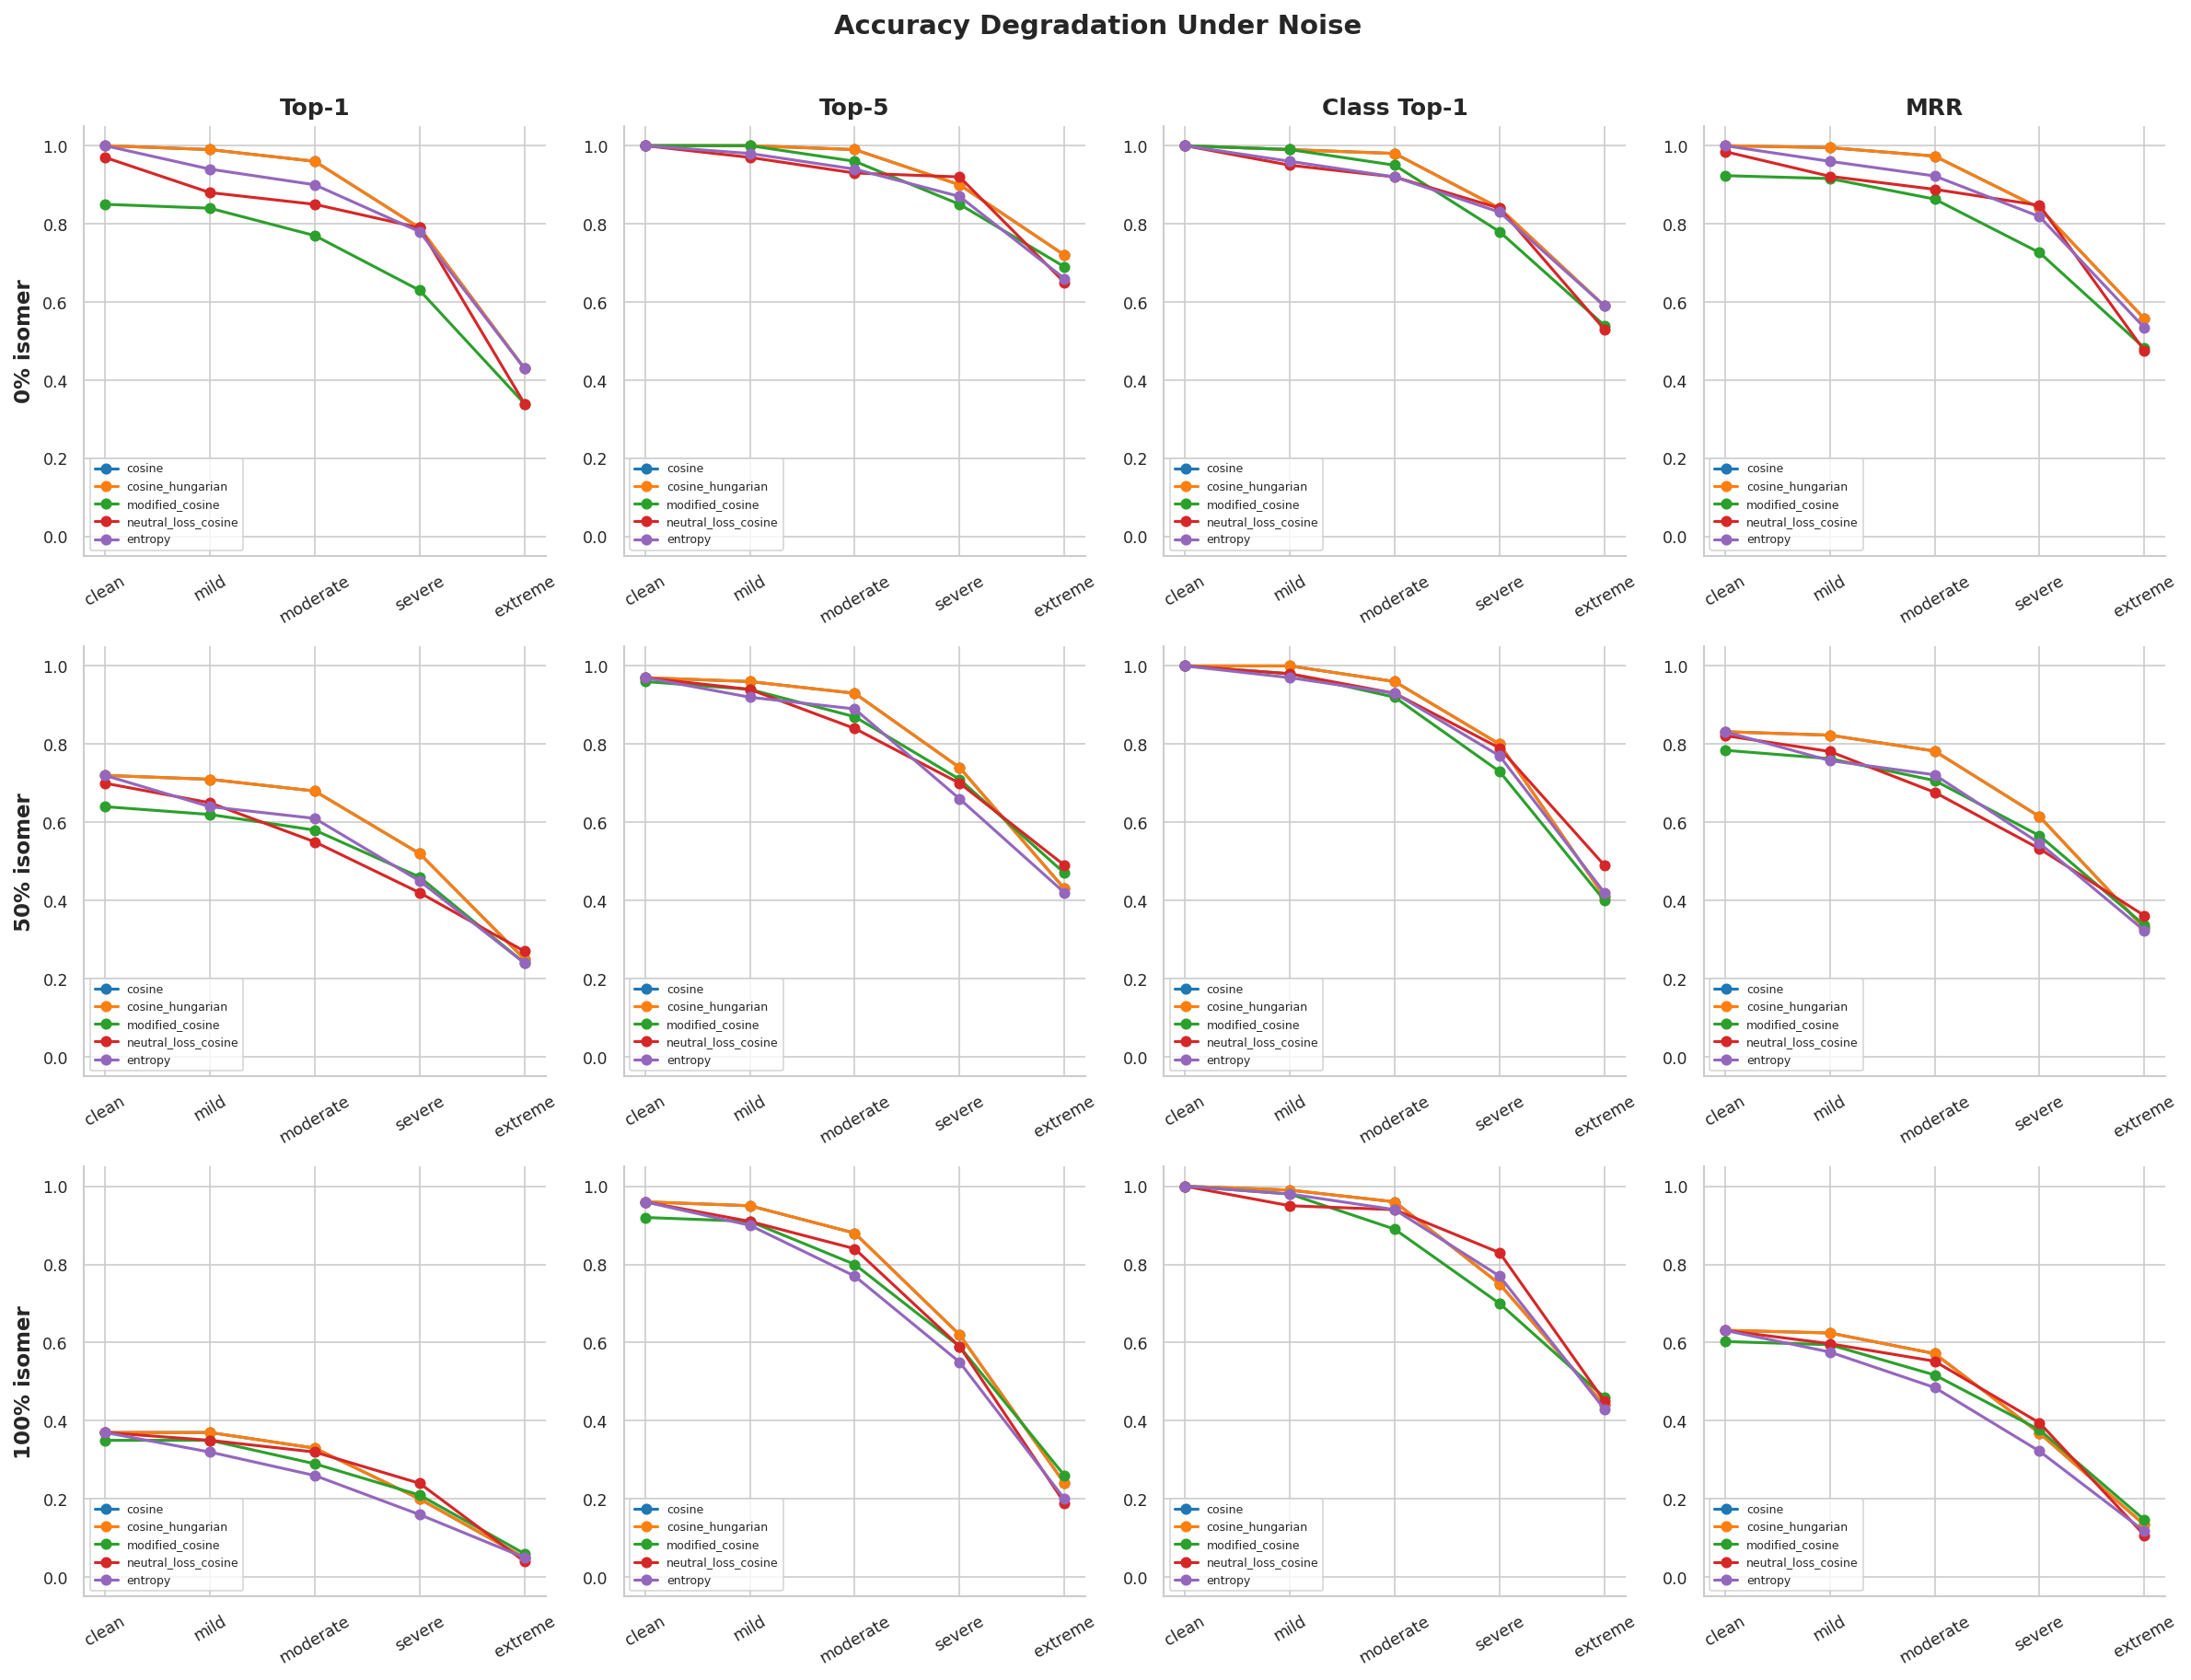

In [12]:
set_labels = list(EVAL_SETS_NAMED.keys())

fig, axes = plt.subplots(len(set_labels), 4, figsize=(16, 4 * len(set_labels)))
for row, label in enumerate(set_labels):
    res = all_results[label]
    for col, (metric, title) in enumerate([("top_1", "Top-1"), ("top_5", "Top-5"),
                                            ("class_top_1", "Class Top-1"), ("mrr", "MRR")]):
        ax = axes[row, col]
        for method in METHODS:
            subset = res[res["method"] == method].set_index("noise").loc[noise_order]
            ax.plot(noise_order, subset[metric], marker="o", label=method, linewidth=1.5)
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=6, loc="lower left")
        if row == 0:
            ax.set_title(title, fontweight="bold")
        if col == 0:
            ax.set_ylabel(label, fontweight="bold", fontsize=11)
        ax.tick_params(axis="x", rotation=30)

plt.suptitle("Accuracy Degradation Under Noise", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 10. Summary

In [13]:
print("=" * 90)
print("BENCHMARK SUMMARY: Classical Methods (Precursor Filter +/-0.5 Da)")
print("=" * 90)
print()
cols = ["eval_set", "method", "noise", "top_1", "class_top_1", "mrr", "mean_query_ms"]
print(split_results[cols].to_string(index=False, float_format="%.3f"))
print()
print("Key findings:")
print("1. Clean accuracy is ~77%, not 100% — entirely due to score degeneracy")
print("   (LipidBlast template sharing creates tied scores; argsort breaks ties randomly)")
print("2. Class-level accuracy is significantly higher than compound-level —")
print("   tied candidates are always isomers of the same class")
print("3. Noise degrades all methods similarly; cosine/cosine_hungarian are best overall")
print("4. No precursor tolerance eliminates the gap — tight loses noisy queries,")
print("   wide adds more degenerate competitors")
print("5. All methods fail on the same degenerate queries — oracle ensemble headroom is minimal")
print("6. Scores provide zero discrimination in the degenerate regime")
print("   (gt_score == top1_score for nearly all misses)")
print()
print("Conclusion: classical spectral similarity hits a fundamental ceiling from")
print("template degeneracy. The path forward requires molecular structure information")
print("(cross-modal alignment) to break ties that spectra alone cannot resolve.")

BENCHMARK SUMMARY: Classical Methods (Precursor Filter +/-0.5 Da)

   eval_set              method    noise  top_1  class_top_1   mrr  mean_query_ms
  0% isomer              cosine    clean  1.000        1.000 1.000         48.963
  0% isomer              cosine     mild  0.990        0.990 0.995         30.276
  0% isomer              cosine moderate  0.960        0.980 0.973         27.578
  0% isomer              cosine   severe  0.790        0.840 0.841         27.103
  0% isomer              cosine  extreme  0.430        0.590 0.557         26.892
  0% isomer    cosine_hungarian    clean  1.000        1.000 1.000         28.510
  0% isomer    cosine_hungarian     mild  0.990        0.990 0.995         28.268
  0% isomer    cosine_hungarian moderate  0.960        0.980 0.973         27.759
  0% isomer    cosine_hungarian   severe  0.790        0.840 0.841         27.491
  0% isomer    cosine_hungarian  extreme  0.430        0.590 0.557         27.062
  0% isomer     modified_cosine

## 11. Per-Query Data Collection

Collect per-query detail that `run_benchmark()` aggregates away.

In [14]:
# Collect per-query detail that run_benchmark() aggregates away.
# For each method on clean queries: full result list (top_k=500 to capture all candidates),
# GT rank, GT score, tie count at top score.

per_query = {}
clean_queries = eval_sets["clean"]

for method_name in METHODS:
    searcher = ClassicalSearcher(ref_df, method=method_name, precursor_tol=0.5)
    rows = []
    for q in tqdm(clean_queries, desc=method_name, leave=False):
        results = searcher.search(q, top_k=500)
        gt_name = q["ground_truth_name"]
        gt_class = q["ground_truth_class"]

        gt_rank, gt_score = None, None
        for r in results:
            if r["name"] == gt_name:
                gt_rank = r["rank"]
                gt_score = r["score"]
                break

        top1_score = results[0]["score"] if results else None
        top1_name = results[0]["name"] if results else None
        hit = (top1_name == gt_name)

        n_ties = sum(1 for r in results
                     if abs(r["score"] - top1_score) < 1e-9) if results else 0

        rows.append({
            "gt_name": gt_name, "gt_class": gt_class, "hit": hit,
            "gt_rank": gt_rank, "gt_score": gt_score,
            "top1_score": top1_score, "top1_name": top1_name,
            "n_ties_at_top": n_ties,
            "n_candidates": results[0]["n_candidates"] if results else 0,
        })

    per_query[method_name] = pd.DataFrame(rows)
    pq = per_query[method_name]
    print(f"{method_name:20s}: {pq['hit'].mean():.1%} top-1, "
          f"{pq['n_ties_at_top'].mean():.1f} mean ties at top score")

cosine              : 69.7% top-1, 2.0 mean ties at top score


cosine_hungarian    : 69.7% top-1, 2.0 mean ties at top score


modified_cosine     : 61.3% top-1, 2.5 mean ties at top score


neutral_loss_cosine : 68.0% top-1, 2.1 mean ties at top score


entropy             : 69.7% top-1, 2.0 mean ties at top score


## 12. Degeneracy Diagnosis

Clean accuracy < 100% is caused by two mechanisms: (1) **tied scores** — spectrally identical isomers produce the same cosine score, so random tiebreaking fails; (2) **template degeneracy** — distinct lipids sharing the same intensity pattern but different m/z positions get similar scores within float tolerance.

Panel 1 below shows the tie-count distribution. Panel 2 decomposes all misses by root cause across noise levels.

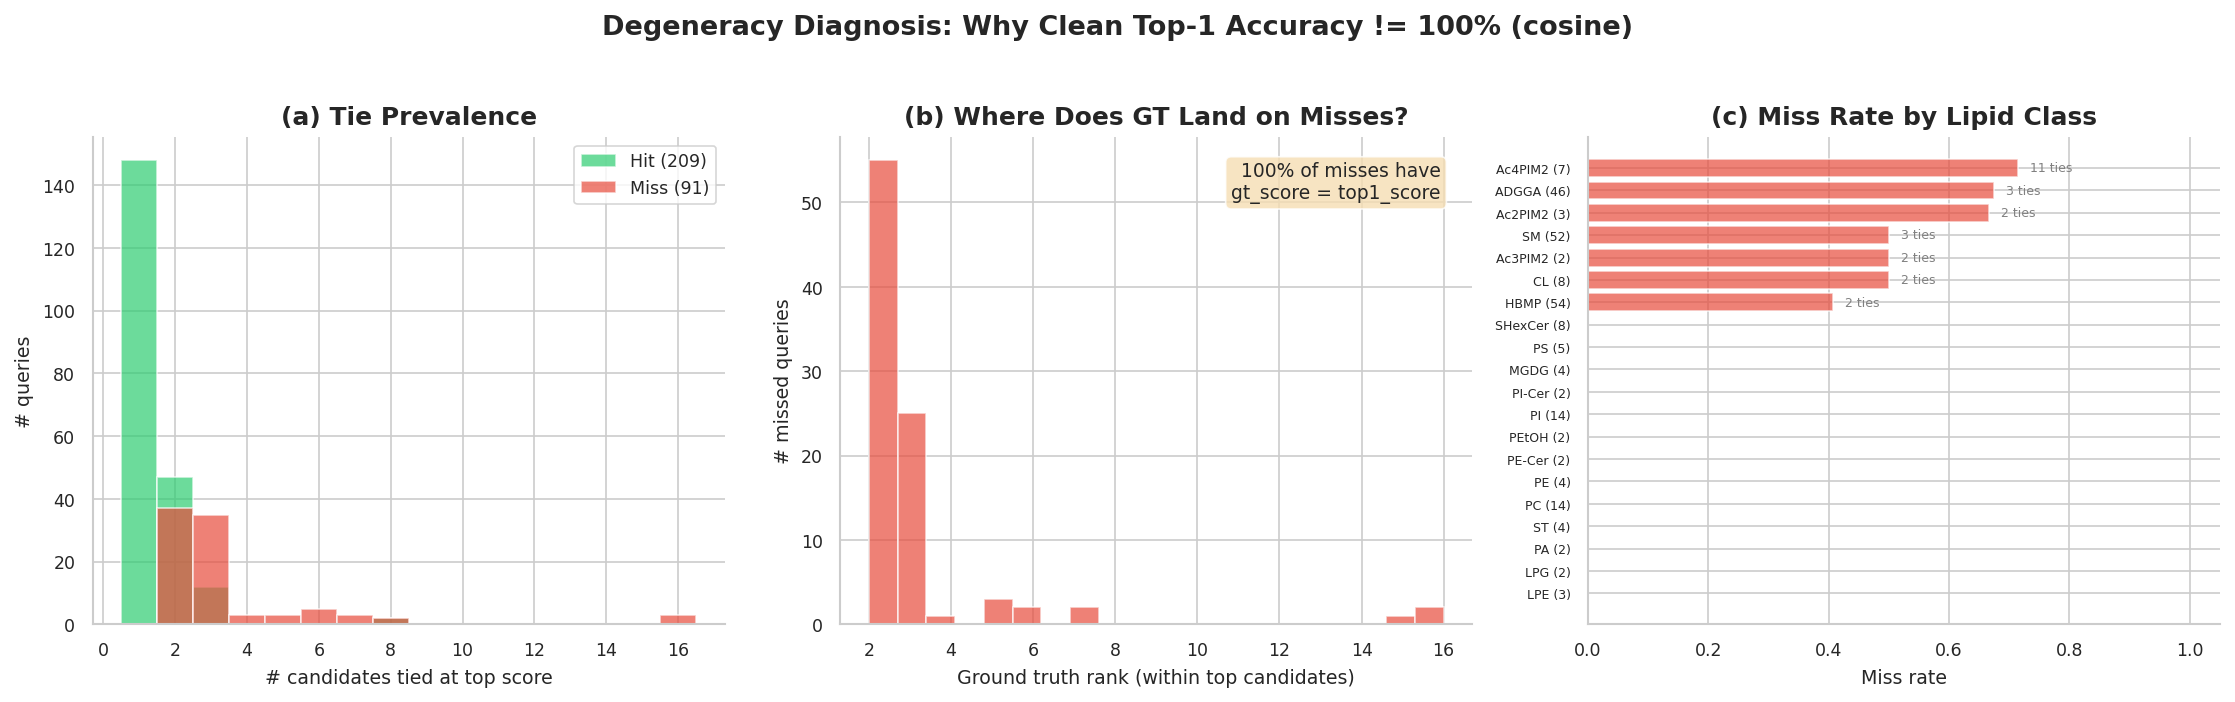

Degeneracy summary (cosine, clean):
  91/300 queries missed (30.3%)
  91/91 misses have gt_score == top1_score (100%) — pure tie-breaking failures
  Mean ties at top: 2.0 (hits: 1.4, misses: 3.5)


In [15]:
pq = per_query["cosine"]
hits = pq[pq["hit"]]
misses = pq[~pq["hit"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Tie prevalence histogram, split by hit/miss
ax = axes[0]
max_ties = int(pq["n_ties_at_top"].max())
bins = np.arange(0.5, max_ties + 1.5, 1)
ax.hist(hits["n_ties_at_top"], bins=bins, alpha=0.7,
        label=f"Hit ({len(hits)})", color="#2ecc71")
ax.hist(misses["n_ties_at_top"], bins=bins, alpha=0.7,
        label=f"Miss ({len(misses)})", color="#e74c3c")
ax.set_xlabel("# candidates tied at top score")
ax.set_ylabel("# queries")
ax.set_title("(a) Tie Prevalence", fontweight="bold")
ax.legend()

# (b) GT rank for misses — where does the correct answer land?
ax = axes[1]
miss_data = misses.dropna(subset=["gt_rank"])
if len(miss_data) > 0:
    ax.hist(miss_data["gt_rank"], bins=20, color="#e74c3c", alpha=0.7, edgecolor="white")
    score_match = (miss_data["gt_score"] - miss_data["top1_score"]).abs() < 1e-9
    pct_tie = score_match.mean()
    ax.text(0.95, 0.95, f"{pct_tie:.0%} of misses have\ngt_score = top1_score",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))
ax.set_xlabel("Ground truth rank (within top candidates)")
ax.set_ylabel("# missed queries")
ax.set_title("(b) Where Does GT Land on Misses?", fontweight="bold")

# (c) Degeneracy by lipid class — miss rate and mean tie count
ax = axes[2]
class_stats = pq.groupby("gt_class").agg(
    n=("hit", "size"),
    miss_rate=("hit", lambda x: 1 - x.mean()),
    mean_ties=("n_ties_at_top", "mean"),
).sort_values("miss_rate", ascending=False)
class_stats = class_stats[class_stats["n"] > 1]
if len(class_stats) > 20:
    class_stats = class_stats.head(20)

y_pos = range(len(class_stats))
ax.barh(y_pos, class_stats["miss_rate"], color="#e74c3c", alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"{c} ({int(n)})" for c, n in zip(class_stats.index, class_stats["n"])],
    fontsize=6)
ax.set_xlabel("Miss rate")
ax.set_title("(c) Miss Rate by Lipid Class", fontweight="bold")
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
for i, (_, row) in enumerate(class_stats.iterrows()):
    if row["miss_rate"] > 0:
        ax.text(min(row["miss_rate"] + 0.02, 0.85), i,
                f"{row['mean_ties']:.0f} ties", va="center", fontsize=6, color="gray")

plt.suptitle("Degeneracy Diagnosis: Why Clean Top-1 Accuracy != 100% (cosine)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Summary stats
n_miss = len(misses)
n_total = len(pq)
if n_miss > 0:
    miss_with_scores = misses.dropna(subset=["gt_score", "top1_score"])
    score_match = (miss_with_scores["gt_score"] - miss_with_scores["top1_score"]).abs() < 1e-9
    print(f"Degeneracy summary (cosine, clean):")
    print(f"  {n_miss}/{n_total} queries missed ({n_miss/n_total:.1%})")
    print(f"  {score_match.sum()}/{len(miss_with_scores)} misses have gt_score == top1_score "
          f"({score_match.mean():.0%}) — pure tie-breaking failures")
    print(f"  Mean ties at top: {pq['n_ties_at_top'].mean():.1f} "
          f"(hits: {hits['n_ties_at_top'].mean():.1f}, "
          f"misses: {misses['n_ties_at_top'].mean():.1f})")

Miss decomposition by noise level:

  clean      (n=300): correct=209 (70%), isomer_tie=91 (30%)
  mild       (n=300): correct=207 (69%), isomer_tie=88 (29%), isomer_overtake=3 (1%), other=2 (1%)
  moderate   (n=300): correct=197 (66%), isomer_tie=83 (28%), isomer_overtake=8 (3%), other=12 (4%)
  severe     (n=300): correct=151 (50%), isomer_tie=69 (23%), isomer_overtake=12 (4%), template_sibling=3 (1%), other=65 (22%)
  extreme    (n=300): correct=73 (24%), isomer_tie=35 (12%), isomer_overtake=12 (4%), template_sibling=22 (7%), other=157 (52%), gt_not_found=1 (0%)


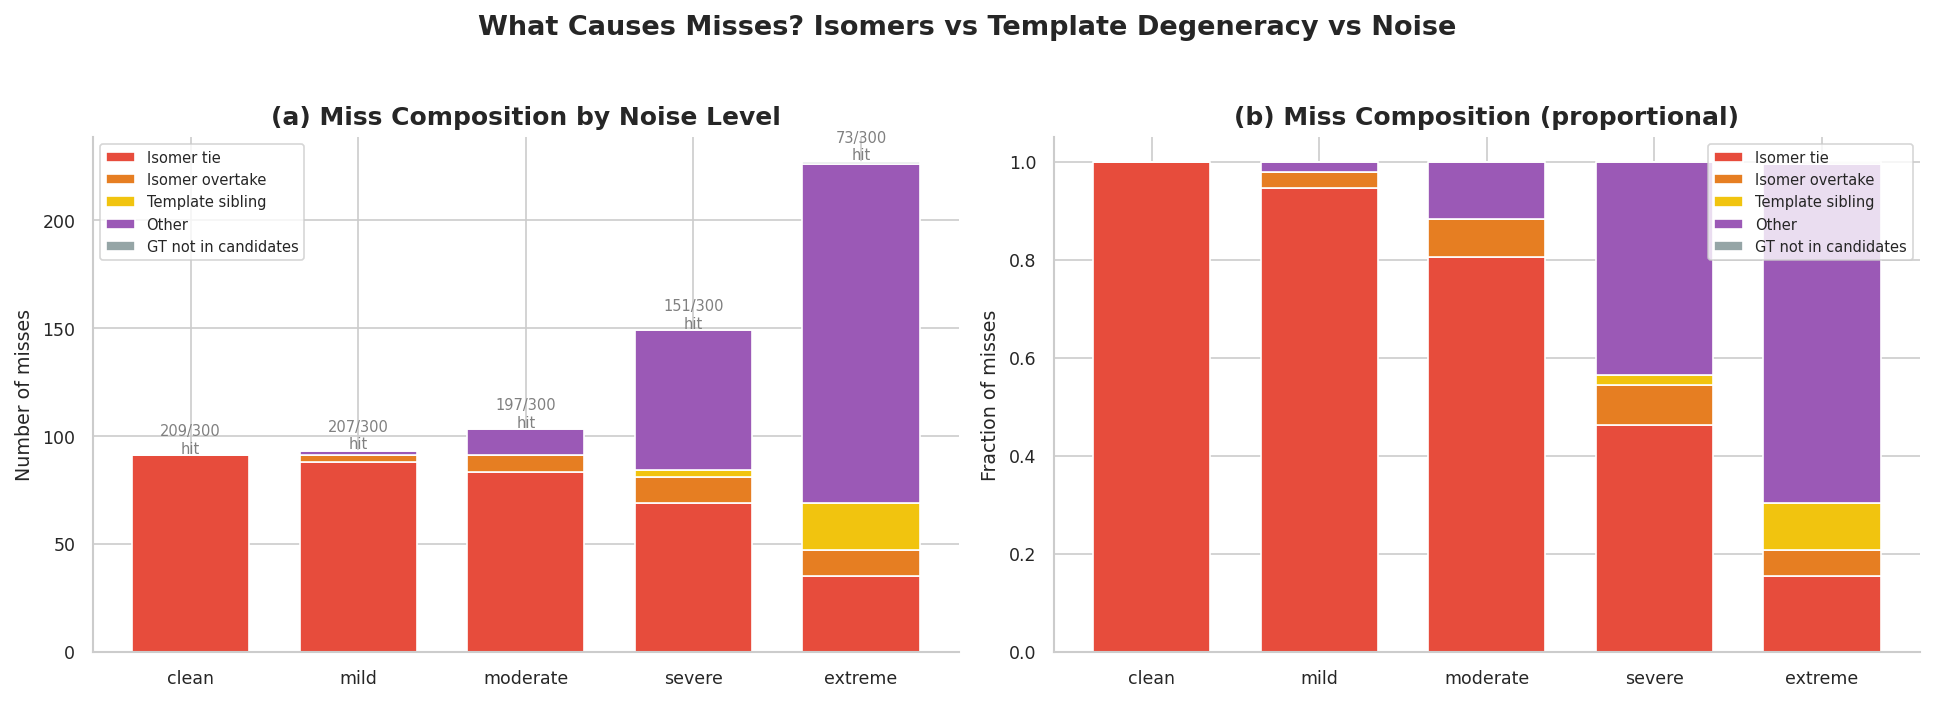

In [19]:
# Classify misses across all noise levels
from src.models.classical import ClassicalSearcher

searcher = ClassicalSearcher(ref_df, method="cosine", precursor_tol=0.5)

# Precompute lookup tables
name_to_group = {}
name_to_template = {}
for _, row in ref_df.iterrows():
    name_to_group[row["name"]] = (row["formula"], row["adduct_name"], row["mode"])
    ints = np.asarray(row["intensity_list"], dtype=np.float64)
    if ints.max() > 0:
        ints = ints / ints.max()
    name_to_template[row["name"]] = tuple(np.round(ints, 6))

noise_order = ["clean", "mild", "moderate", "severe", "extreme"]
decomp_rows = []

for noise_name in noise_order:
    queries = eval_sets[noise_name]

    for q in tqdm(queries, desc=noise_name, leave=False):
        gt_name = q["ground_truth_name"]
        results = searcher.search(q, top_k=500)
        if not results:
            continue

        top1_name = results[0]["name"]
        top1_score = results[0]["score"]
        hit = (top1_name == gt_name)

        # Find GT score
        gt_score = None
        for r in results:
            if r["name"] == gt_name:
                gt_score = r["score"]
                break

        if hit:
            cause = "correct"
        elif gt_score is None:
            cause = "gt_not_found"
        else:
            gt_group = name_to_group[gt_name]
            top1_group = name_to_group.get(top1_name)
            gt_template = name_to_template[gt_name]
            top1_template = name_to_template.get(top1_name)

            is_isomer = (top1_group == gt_group)
            is_tie = abs(top1_score - gt_score) < 1e-9
            is_template_sibling = (gt_template == top1_template) and not is_isomer

            if is_isomer and is_tie:
                cause = "isomer_tie"
            elif is_isomer and not is_tie:
                cause = "isomer_overtake"
            elif is_template_sibling:
                cause = "template_sibling"
            else:
                cause = "other"

        decomp_rows.append({
            "noise": noise_name,
            "gt_name": gt_name,
            "cause": cause,
            "top1_score": top1_score,
            "gt_score": gt_score,
        })

decomp_df = pd.DataFrame(decomp_rows)

# Summary table
print("Miss decomposition by noise level:\n")
cause_order = ["correct", "isomer_tie", "isomer_overtake", "template_sibling", "other", "gt_not_found"]
for noise in noise_order:
    sub = decomp_df[decomp_df["noise"] == noise]
    counts = sub["cause"].value_counts()
    n = len(sub)
    parts = []
    for c in cause_order:
        if c in counts.index and counts[c] > 0:
            parts.append(f"{c}={counts[c]} ({counts[c]/n:.0%})")
    print(f"  {noise:10s} (n={n}): {', '.join(parts)}")

# --- Stacked bar chart ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

miss_causes = ["isomer_tie", "isomer_overtake", "template_sibling", "other", "gt_not_found"]
cause_colors = {
    "isomer_tie": "#e74c3c",
    "isomer_overtake": "#e67e22",
    "template_sibling": "#f1c40f",
    "other": "#9b59b6",
    "gt_not_found": "#95a5a6",
}
cause_labels = {
    "isomer_tie": "Isomer tie",
    "isomer_overtake": "Isomer overtake",
    "template_sibling": "Template sibling",
    "other": "Other",
    "gt_not_found": "GT not in candidates",
}

# (a) Stacked bar: miss composition by noise level
x = np.arange(len(noise_order))
bottom = np.zeros(len(noise_order))
for cause in miss_causes:
    heights = []
    for noise in noise_order:
        sub = decomp_df[(decomp_df["noise"] == noise) & (decomp_df["cause"] == cause)]
        heights.append(len(sub))
    heights = np.array(heights)
    if heights.sum() > 0:
        ax1.bar(x, heights, bottom=bottom, color=cause_colors[cause],
                label=cause_labels[cause], edgecolor="white", width=0.7)
        bottom += heights

# Add correct count on top as text
for i, noise in enumerate(noise_order):
    n_correct = len(decomp_df[(decomp_df["noise"] == noise) & (decomp_df["cause"] == "correct")])
    n_total = len(decomp_df[decomp_df["noise"] == noise])
    ax1.text(i, bottom[i] + 1, f"{n_correct}/{n_total}\nhit", ha="center", fontsize=7, color="gray")

ax1.set_xticks(x)
ax1.set_xticklabels(noise_order)
ax1.set_ylabel("Number of misses")
ax1.set_title("(a) Miss Composition by Noise Level", fontweight="bold")
ax1.legend(fontsize=7, loc="upper left")

# (b) Stacked bar: proportional
bottom = np.zeros(len(noise_order))
for cause in miss_causes:
    heights = []
    for noise in noise_order:
        sub_all = decomp_df[(decomp_df["noise"] == noise) & (decomp_df["cause"] != "correct")]
        sub_cause = decomp_df[(decomp_df["noise"] == noise) & (decomp_df["cause"] == cause)]
        n_miss = len(sub_all)
        heights.append(len(sub_cause) / n_miss if n_miss > 0 else 0)
    heights = np.array(heights)
    if heights.sum() > 0:
        ax2.bar(x, heights, bottom=bottom, color=cause_colors[cause],
                label=cause_labels[cause], edgecolor="white", width=0.7)
        bottom += heights

ax2.set_xticks(x)
ax2.set_xticklabels(noise_order)
ax2.set_ylabel("Fraction of misses")
ax2.set_title("(b) Miss Composition (proportional)", fontweight="bold")
ax2.legend(fontsize=7, loc="upper right")
ax2.set_ylim(0, 1.05)

plt.suptitle("What Causes Misses? Isomers vs Template Degeneracy vs Noise",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 13. Precursor Tolerance Sweep

Sweep precursor tolerance to find the best accuracy-speed tradeoff.

  +/-0.05 Da done
  +/-0.1 Da done
  +/-0.2 Da done
  +/-0.5 Da done
  +/-1.0 Da done
  +/-2.0 Da done


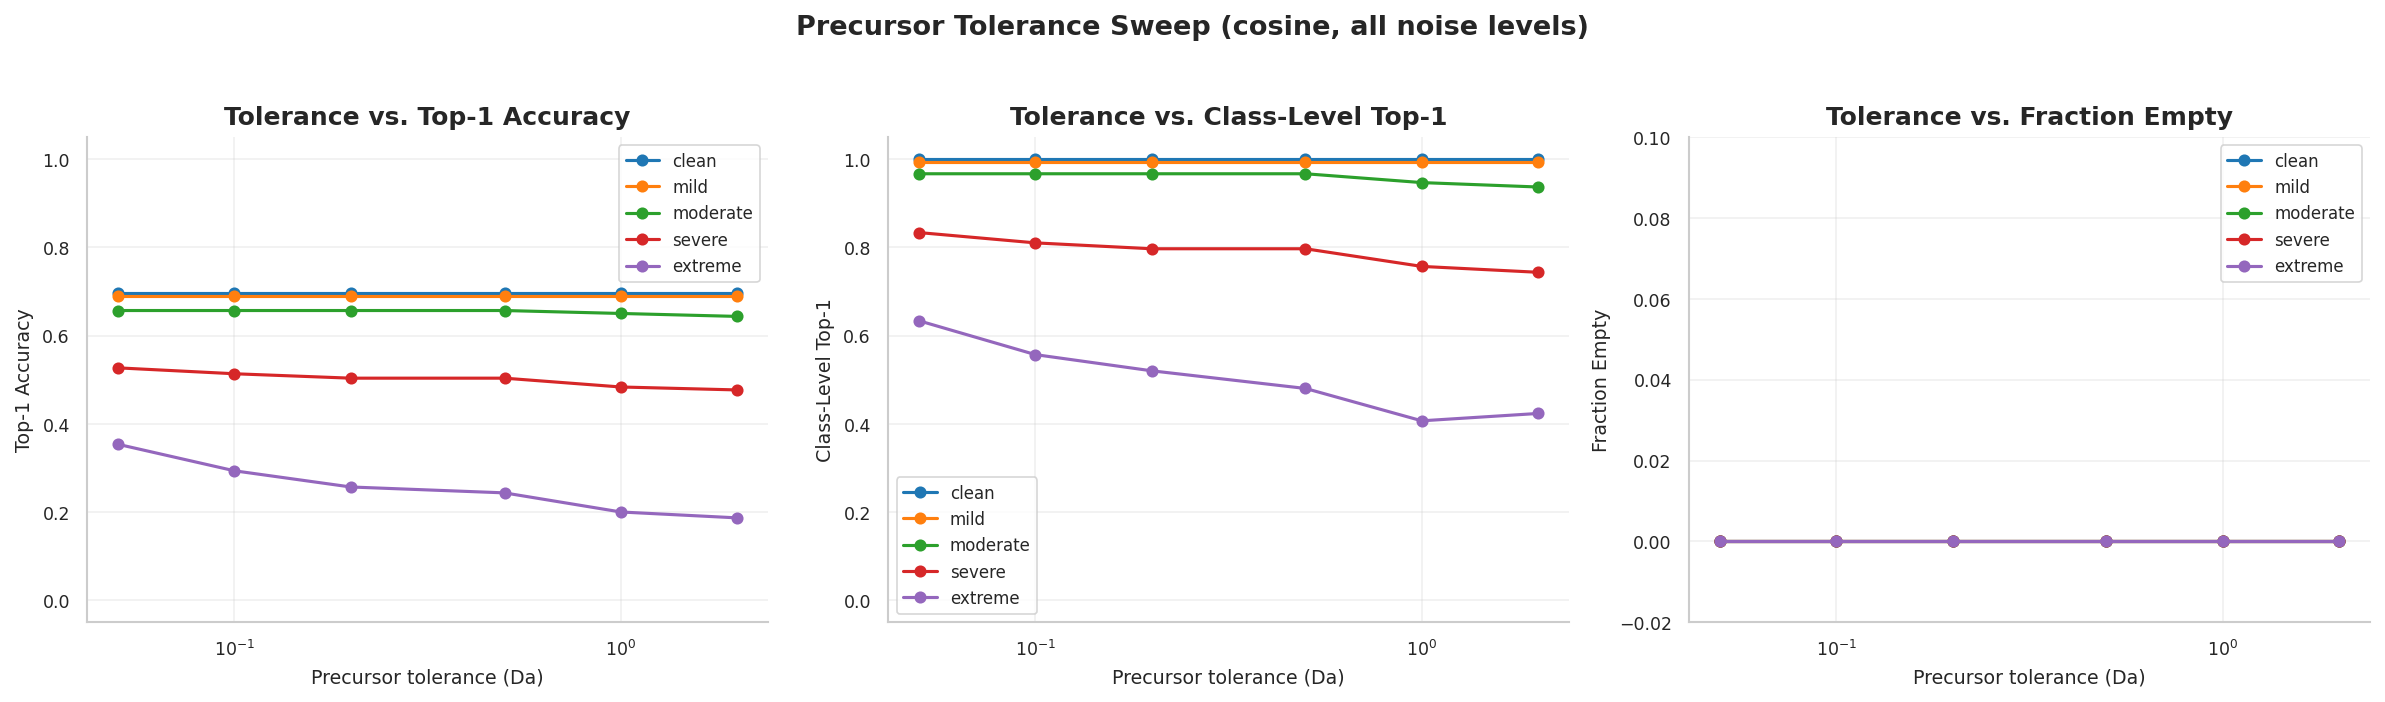


Tolerance sweep summary (cosine, clean):
  +/-0.05  Da: top1=0.697, class_top1=1.000, empty=0.0%
  +/-0.10  Da: top1=0.697, class_top1=1.000, empty=0.0%
  +/-0.20  Da: top1=0.697, class_top1=1.000, empty=0.0%
  +/-0.50  Da: top1=0.697, class_top1=1.000, empty=0.0%
  +/-1.00  Da: top1=0.697, class_top1=1.000, empty=0.0%
  +/-2.00  Da: top1=0.697, class_top1=1.000, empty=0.0%


In [20]:
SWEEP_TOLS = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
noise_levels = ["clean", "mild", "moderate", "severe", "extreme"]
from src.utils.metrics import class_level_accuracy

sweep_rows = []
for tol in SWEEP_TOLS:
    searcher = ClassicalSearcher(ref_df, method="cosine", precursor_tol=tol)
    for noise_name in noise_levels:
        queries = eval_sets[noise_name]
        preds, gts, pred_classes, gt_classes = [], [], [], []
        n_empty = 0
        for q in queries:
            results = searcher.search(q, top_k=10)
            preds.append([r["name"] for r in results])
            gts.append(q["ground_truth_name"])
            pred_classes.append([r.get("lipid_class", "") for r in results])
            gt_classes.append(q["ground_truth_class"])
            if len(results) == 0:
                n_empty += 1

        sweep_rows.append({
            "tol": tol, "noise": noise_name,
            "top_1": top_k_accuracy(preds, gts, 1),
            "class_top_1": class_level_accuracy(pred_classes, gt_classes, 1),
            "frac_empty": n_empty / len(queries),
        })
    print(f"  +/-{tol} Da done")

sweep_df = pd.DataFrame(sweep_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for noise in noise_levels:
    sub = sweep_df[sweep_df["noise"] == noise]
    axes[0].plot(sub["tol"], sub["top_1"], marker="o", label=noise, linewidth=1.5)
    axes[1].plot(sub["tol"], sub["class_top_1"], marker="o", label=noise, linewidth=1.5)
    axes[2].plot(sub["tol"], sub["frac_empty"], marker="o", label=noise, linewidth=1.5)

for ax, title in zip(axes, ["Top-1 Accuracy", "Class-Level Top-1", "Fraction Empty"]):
    ax.set_xscale("log")
    ax.set_xlabel("Precursor tolerance (Da)")
    ax.set_ylabel(title)
    ax.set_title(f"Tolerance vs. {title}", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)
axes[2].set_ylim(-0.02, max(0.1, sweep_df["frac_empty"].max() * 1.3))

plt.suptitle("Precursor Tolerance Sweep (cosine, all noise levels)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print("\nTolerance sweep summary (cosine, clean):")
for _, row in sweep_df[sweep_df["noise"] == "clean"].iterrows():
    print(f"  +/-{row['tol']:<5.2f} Da: top1={row['top_1']:.3f}, "
          f"class_top1={row['class_top_1']:.3f}, empty={row['frac_empty']:.1%}")

## 14. Per-Class Breakdown and Score Distributions

Which lipid classes are hardest, and can the score itself discriminate correct from incorrect predictions?

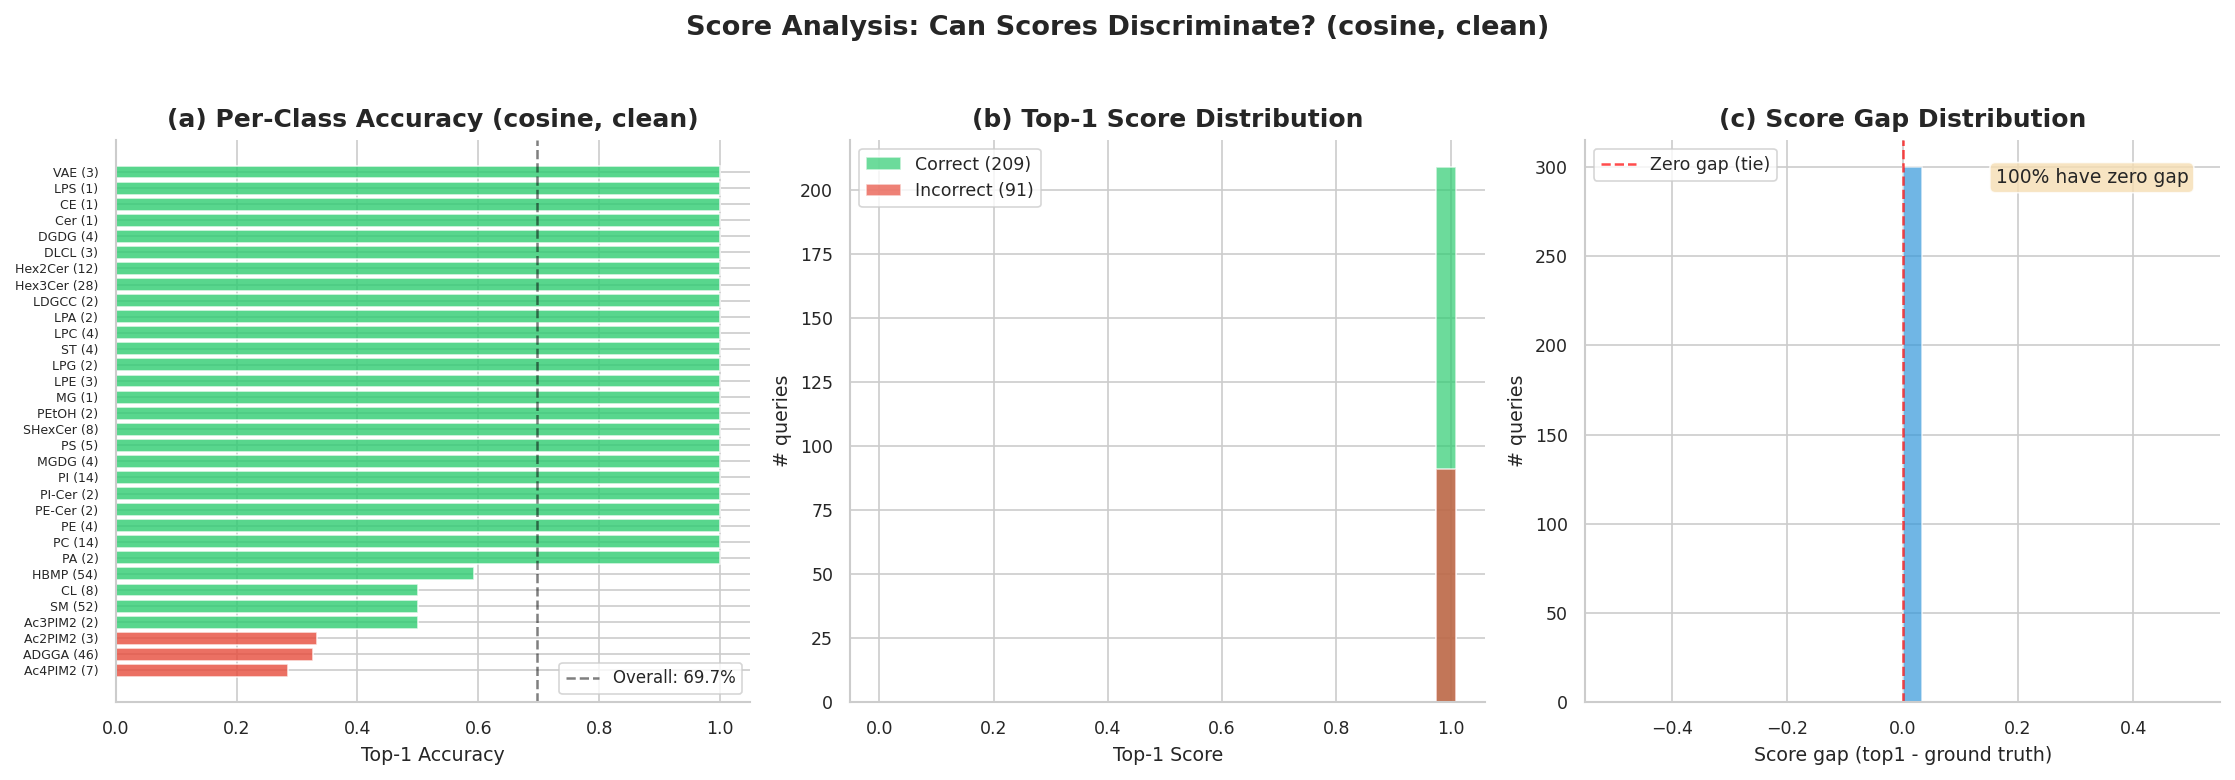

In [21]:
pq = per_query["cosine"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Per-class top-1 accuracy bar chart
ax = axes[0]
class_acc = pq.groupby("gt_class")["hit"].agg(["mean", "size"]).rename(
    columns={"mean": "accuracy", "size": "n"})
class_acc = class_acc.sort_values("accuracy")
colors = ["#e74c3c" if acc < 0.5 else "#2ecc71" for acc in class_acc["accuracy"]]
y_pos = range(len(class_acc))
ax.barh(y_pos, class_acc["accuracy"], color=colors, alpha=0.8, edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{c} ({int(n)})" for c, n in zip(class_acc.index, class_acc["n"])],
                    fontsize=6)
ax.set_xlabel("Top-1 Accuracy")
ax.set_title("(a) Per-Class Accuracy (cosine, clean)", fontweight="bold")
ax.axvline(pq["hit"].mean(), color="black", linestyle="--", alpha=0.5,
           label=f"Overall: {pq['hit'].mean():.1%}")
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05)

# (b) Score distribution: correct vs incorrect
ax = axes[1]
hits = pq[pq["hit"]]
misses = pq[~pq["hit"]]
bins = np.linspace(0, 1.01, 30)
ax.hist(hits["top1_score"].dropna(), bins=bins, alpha=0.7,
        label=f"Correct ({len(hits)})", color="#2ecc71")
ax.hist(misses["top1_score"].dropna(), bins=bins, alpha=0.7,
        label=f"Incorrect ({len(misses)})", color="#e74c3c")
ax.set_xlabel("Top-1 Score")
ax.set_ylabel("# queries")
ax.set_title("(b) Top-1 Score Distribution", fontweight="bold")
ax.legend()

# (c) Score gap: top1_score - gt_score
ax = axes[2]
valid = pq.dropna(subset=["gt_score", "top1_score"])
score_gap = valid["top1_score"] - valid["gt_score"]
ax.hist(score_gap, bins=30, color="#3498db", alpha=0.7, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", alpha=0.7, label="Zero gap (tie)")
ax.set_xlabel("Score gap (top1 - ground truth)")
ax.set_ylabel("# queries")
ax.set_title("(c) Score Gap Distribution", fontweight="bold")
pct_zero = (score_gap.abs() < 1e-9).mean()
ax.text(0.95, 0.95, f"{pct_zero:.0%} have zero gap",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))
ax.legend()

plt.suptitle("Score Analysis: Can Scores Discriminate? (cosine, clean)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 15. Method Agreement and Complementarity

Are the 5 methods making independent errors, or failing on the same queries? If redundant, ensembling won't help.

Method agreement (300 clean queries, 5 methods):
  All correct:  184/300 (61.3%)
  All wrong:    91/300 (30.3%)
  Disagree:     25/300 (8.3%)
  Oracle (any): 69.7%
  Best single:  69.7%
  Headroom:     0.0%


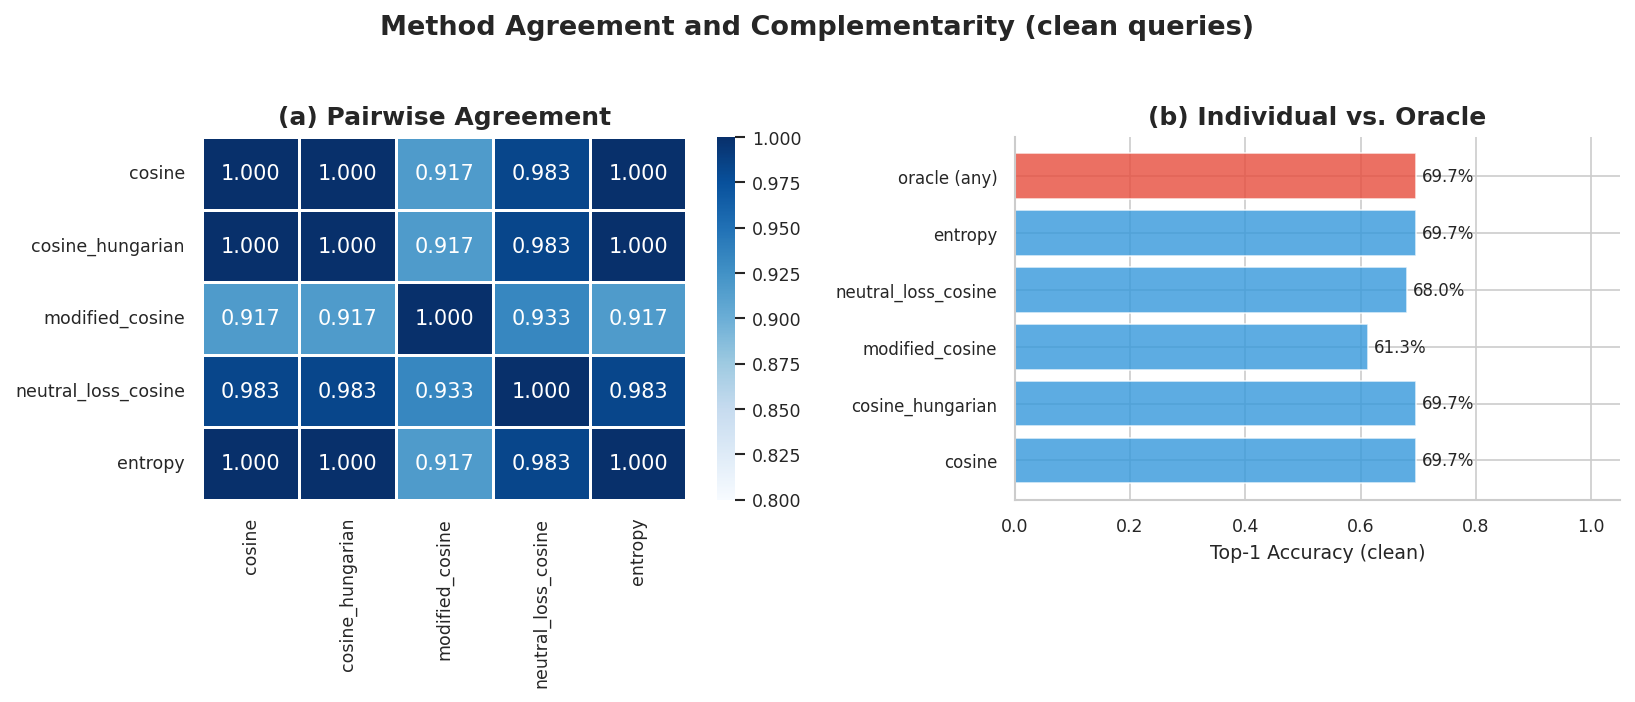

In [22]:
# Build hit/miss matrix: n_queries × 5 methods
hit_matrix = pd.DataFrame({m: per_query[m]["hit"] for m in METHODS})

n_queries = len(hit_matrix)
all_correct = hit_matrix.all(axis=1).sum()
all_wrong = (~hit_matrix).all(axis=1).sum()
disagree = n_queries - all_correct - all_wrong
oracle = hit_matrix.any(axis=1).mean()
best_single = max(per_query[m]["hit"].mean() for m in METHODS)

print(f"Method agreement ({n_queries} clean queries, {len(METHODS)} methods):")
print(f"  All correct:  {all_correct}/{n_queries} ({all_correct/n_queries:.1%})")
print(f"  All wrong:    {all_wrong}/{n_queries} ({all_wrong/n_queries:.1%})")
print(f"  Disagree:     {disagree}/{n_queries} ({disagree/n_queries:.1%})")
print(f"  Oracle (any): {oracle:.1%}")
print(f"  Best single:  {best_single:.1%}")
print(f"  Headroom:     {oracle - best_single:.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# (a) Pairwise agreement heatmap
agreement = pd.DataFrame(index=METHODS, columns=METHODS, dtype=float)
for m1 in METHODS:
    for m2 in METHODS:
        agreement.loc[m1, m2] = (hit_matrix[m1] == hit_matrix[m2]).mean()

sns.heatmap(agreement.astype(float), annot=True, fmt=".3f", cmap="Blues",
            vmin=0.8, vmax=1, ax=ax1, linewidths=0.5)
ax1.set_title("(a) Pairwise Agreement", fontweight="bold")

# (b) Per-method accuracy + oracle
ax = ax2
method_accs = {m: per_query[m]["hit"].mean() for m in METHODS}
method_accs["oracle (any)"] = oracle
names = list(method_accs.keys())
vals = list(method_accs.values())
colors = ["#3498db"] * len(METHODS) + ["#e74c3c"]
ax.barh(range(len(names)), vals, color=colors, alpha=0.8, edgecolor="white")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("Top-1 Accuracy (clean)")
ax.set_title("(b) Individual vs. Oracle", fontweight="bold")
for i, v in enumerate(vals):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=8)
ax.set_xlim(0, 1.05)

plt.suptitle("Method Agreement and Complementarity (clean queries)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()